# Aprendizado por Reforço — Exemplos em Python
### GCC1734 Inteligência Artificial · CEFET/RJ

Este notebook reúne todos os exemplos de código que acompanham as
**Notas de Aula de Aprendizado por Reforço** (Prof. Eduardo Bezerra).
Cada seção corresponde a uma seção das notas e pode ser executada
de forma independente.

---


In [18]:
# ── Configuração global ───────────────────────────────────────
import random, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
random.seed(42); np.random.seed(42)

# ── Definição compartilhada do Mundo Grade 4×3 ───────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})
NAO_T    = [s for s in ESTADOS if s not in ((4, 3), (4, 2))]
T_POS, T_NEG = (4, 3), (4, 2)
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0,1), 'S': (0,-1), 'L': (1,0), 'O': (-1,0)}
PERP     = {'N': ('O','L'), 'S': ('L','O'), 'L': ('N','S'), 'O': ('S','N')}
D_MAX    = 6.0

def mover(s, a):
    c, r = s; dc, dr = DELTA[a]; s2 = (c+dc, r+dr)
    return s2 if s2 in ESTADOS else s

def amostrar(s, a):
    ae, ad = PERP[a]
    return random.choices([mover(s,a), mover(s,ae), mover(s,ad)],
                          weights=[0.8, 0.1, 0.1])[0]

def recomp(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

SETA = {'N':'↑','S':'↓','L':'→','O':'←'}

def plot_grade(politica, titulo='Política', ax=None):
    """Plota a grade 4×3 com setas da política."""
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(5, 4))
    ax.set_xlim(0.5, 4.5); ax.set_ylim(0.5, 3.5)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(titulo)
    for col in range(1, 5):
        for row in range(1, 4):
            s = (col, row)
            fc = ('#444' if s==(2,2) else '#90EE90' if s==T_POS
                  else '#FFB6C1' if s==T_NEG else 'white')
            ax.add_patch(plt.Rectangle((col-.5,row-.5),1,1,ec='gray',fc=fc,lw=1.2))
            if   s == T_POS: ax.text(col,row,'+1',ha='center',va='center',
                                     fontsize=11,fontweight='bold')
            elif s == T_NEG: ax.text(col,row,'−1',ha='center',va='center',
                                     fontsize=11,fontweight='bold')
            elif s != (2,2) and s in politica:
                ax.text(col,row,SETA[politica[s]],ha='center',va='center',fontsize=22)
    if standalone: plt.tight_layout(); plt.show()

print("✓  Configuração carregada.")


✓  Configuração carregada.


---
## Seção 1 — Ciclo Agente–Ambiente
**Conceito:** vocabulário básico do AR — estado, ação, recompensa, transição.  
O agente age aleatoriamente. Nenhum aprendizado ocorre.


In [19]:
"""
01_ciclo_ar.py — Seção 1: Ciclo agente–ambiente
Ilustra o ciclo básico: o agente observa um estado, escolhe
uma ação aleatória e recebe recompensa + próximo estado.
Nenhum aprendizado ocorre — objetivo: fixar o vocabulário.
"""
import random

# ── Mundo Grade 4×3 ──────────────────────────────────────────
ESTADOS  = {(c, r) for c in range(1, 5) for r in range(1, 4)} - {(2, 2)}
T_POS    = (4, 3)   # terminal com recompensa +1
T_NEG    = (4, 2)   # terminal com recompensa -1
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}

def mover(s, a):
    """Transição determinística (sem estocasticidade)."""
    c, r = s
    dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s   # bate na parede: fica no lugar

def recompensa(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

def is_terminal(s):
    return s in (T_POS, T_NEG)

# ── Episódio com política aleatória ──────────────────────────
random.seed(42)
s = (1, 1)

print("=" * 60)
print("  Ciclo Agente–Ambiente  |  política aleatória")
print("=" * 60)
print(f"  Estado inicial: {s}")
print()
print(f"  {'Passo':>5}  {'s':>6}  {'a':>3}  {'r':>6}  {'s_novo':>6}")
print("  " + "─" * 38)

G = 0.0
for passo in range(1, 25):
    a      = random.choice(ACOES)
    s_novo = mover(s, a)
    r      = recompensa(s_novo)
    G     += r
    flag   = "  ← TERMINAL" if is_terminal(s_novo) else ""
    print(f"  {passo:>5}  {str(s):>6}  {a:>3}  {r:>6.2f}  {str(s_novo):>6}{flag}")
    if is_terminal(s_novo):
        break
    s = s_novo

print()
print(f"  Retorno total não descontado: G = {G:.2f}")
print()
print("  Vocabulário fixado:")
print("    s       → estado observado antes da ação")
print("    a       → ação executada pelo agente")
print("    r       → recompensa imediata recebida")
print("    s_novo  → próximo estado (resultado da ação)")
print("    (s, a, r, s_novo) = uma transição / experiência")


  Ciclo Agente–Ambiente  |  política aleatória
  Estado inicial: (1, 1)

  Passo       s    a       r  s_novo
  ──────────────────────────────────────
      1  (1, 1)    N   -0.04  (1, 2)
      2  (1, 2)    N   -0.04  (1, 3)
      3  (1, 3)    L   -0.04  (2, 3)
      4  (2, 3)    S   -0.04  (2, 3)
      5  (2, 3)    S   -0.04  (2, 3)
      6  (2, 3)    S   -0.04  (2, 3)
      7  (2, 3)    N   -0.04  (2, 3)
      8  (2, 3)    N   -0.04  (2, 3)
      9  (2, 3)    O   -0.04  (1, 3)
     10  (1, 3)    N   -0.04  (1, 3)
     11  (1, 3)    N   -0.04  (1, 3)
     12  (1, 3)    N   -0.04  (1, 3)
     13  (1, 3)    S   -0.04  (1, 2)
     14  (1, 2)    S   -0.04  (1, 1)
     15  (1, 1)    N   -0.04  (1, 2)
     16  (1, 2)    S   -0.04  (1, 1)
     17  (1, 1)    O   -0.04  (1, 1)
     18  (1, 1)    S   -0.04  (1, 1)
     19  (1, 1)    O   -0.04  (1, 1)
     20  (1, 1)    L   -0.04  (2, 1)
     21  (2, 1)    N   -0.04  (2, 1)
     22  (2, 1)    S   -0.04  (2, 1)
     23  (2, 1)    O   -0.04  (1, 1

---
## Seção 2 — Processo de Decisão de Markov (PDM)
**Conceito:** os cinco componentes do PDM — S, A, T, R, γ.  
Verificação formal de que Σ T(s,a,s') = 1 e simulação estocástica.


In [20]:
"""
02_mundo_grade_pdm.py — Seção 2: PDM do Mundo Grade 4×3
Define formalmente os cinco componentes do PDM: S, A, T, R, γ.
Verifica que Σ T(s,a,s') = 1 para todo (s,a).
Exibe T((1,1), N) em detalhe e simula um episódio estocástico.
"""
import random
from collections import defaultdict

# ── Componentes do PDM ───────────────────────────────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})   # S
ACOES    = ['N', 'S', 'L', 'O']                        # A
GAMMA    = 0.9                                          # γ
T_POS, T_NEG = (4, 3), (4, 2)
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}
PERP     = {'N': ('O', 'L'), 'S': ('L', 'O'),          # perpendiculares
             'L': ('N', 'S'), 'O': ('S', 'N')}

def R(s):
    """Função de recompensa R(s) — depende apenas do estado destino."""
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

def mover(s, a):
    c, r = s
    dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s

def T(s, a):
    """Modelo de transição: retorna dict {s': prob} para o par (s,a).
       0.8 → direção pretendida; 0.1 → cada perpendicular."""
    ae, ad = PERP[a]
    dist = defaultdict(float)
    dist[mover(s, a)]  += 0.8
    dist[mover(s, ae)] += 0.1
    dist[mover(s, ad)] += 0.1
    return dict(dist)

def amostrar(s, a):
    """Amostra um s' segundo T(s,a)."""
    d = T(s, a)
    return random.choices(list(d.keys()), weights=list(d.values()))[0]

# ── Informações gerais ────────────────────────────────────────
print("=" * 58)
print("  PDM — Mundo Grade 4×3")
print("=" * 58)
print(f"\n  |S| = {len(ESTADOS)} estados  |A| = {len(ACOES)} ações  γ = {GAMMA}\n")
print("  Componentes do PDM:")
print("    S  → 11 células não bloqueadas (inclui terminais)")
print("    A  → {N, S, L, O}")
print("    T  → estocástica: 0.8 pretendida, 0.1 cada perpendicular")
print("    R  → +1 terminal+, −1 terminal−, −0.04 demais")
print(f"    γ  → {GAMMA}\n")

# ── Verificação: Σ T(s,a,s') = 1 ────────────────────────────
erros = [(s, a) for s in ESTADOS for a in ACOES
         if abs(sum(T(s, a).values()) - 1.0) > 1e-9]
if erros:
    print(f"  ERRO: distribuições inválidas em {erros}")
else:
    print("  ✓  Σ T(s,a,s') = 1.00 para todo (s,a)\n")

# ── Exemplo detalhado: T((1,1), 'N') ─────────────────────────
print("  T((1,1), 'N')  — ação Norte a partir do canto inferior esquerdo:")
for s2, p in sorted(T((1,1), 'N').items(), key=lambda x: -x[1]):
    print(f"    P(s'={s2} | s=(1,1), a=N) = {p:.2f}   R(s')={R(s2):+.2f}")

# ── Episódio estocástico ──────────────────────────────────────
random.seed(7)
print("\n  Episódio estocástico a partir de (1,1)  [γ=0.9]:")
s, G, t = (1, 1), 0.0, 0
while s not in (T_POS, T_NEG) and t < 40:
    a  = random.choice(ACOES)
    s2 = amostrar(s, a)
    r  = R(s2)
    G += (GAMMA ** t) * r
    print(f"    t={t:>2}: {s} --{a}--> {s2}   r={r:+.2f}")
    s = s2; t += 1

print(f"\n  Retorno descontado do episódio: G = {G:.4f}")


  PDM — Mundo Grade 4×3

  |S| = 11 estados  |A| = 4 ações  γ = 0.9

  Componentes do PDM:
    S  → 11 células não bloqueadas (inclui terminais)
    A  → {N, S, L, O}
    T  → estocástica: 0.8 pretendida, 0.1 cada perpendicular
    R  → +1 terminal+, −1 terminal−, −0.04 demais
    γ  → 0.9

  ✓  Σ T(s,a,s') = 1.00 para todo (s,a)

  T((1,1), 'N')  — ação Norte a partir do canto inferior esquerdo:
    P(s'=(1, 2) | s=(1,1), a=N) = 0.80   R(s')=-0.04
    P(s'=(1, 1) | s=(1,1), a=N) = 0.10   R(s')=-0.04
    P(s'=(2, 1) | s=(1,1), a=N) = 0.10   R(s')=-0.04

  Episódio estocástico a partir de (1,1)  [γ=0.9]:
    t= 0: (1, 1) --L--> (1, 1)   r=-0.04
    t= 1: (1, 1) --O--> (1, 1)   r=-0.04
    t= 2: (1, 1) --N--> (1, 1)   r=-0.04
    t= 3: (1, 1) --N--> (1, 2)   r=-0.04
    t= 4: (1, 2) --N--> (1, 2)   r=-0.04
    t= 5: (1, 2) --S--> (1, 1)   r=-0.04
    t= 6: (1, 1) --O--> (1, 1)   r=-0.04
    t= 7: (1, 1) --S--> (1, 1)   r=-0.04
    t= 8: (1, 1) --O--> (1, 1)   r=-0.04
    t= 9: (1, 1) --N

---
## Seção 3a — Equação de Bellman (cálculo manual)
**Conceito:** Q*(s,a), V*(s) e política ótima π*(s).  
Reproduz **exatamente** o exemplo numérico do texto: Q((3,2), Norte) = 0.485.


In [21]:
"""
03_bellman_manual.py — Seção 3: Equação de Bellman
Reproduz passo a passo os exemplos numéricos do texto:
  • Cálculo de Q((3,2), Norte) = 0.485
  • V*((3,2)) = max_a Q((3,2), a)
  • Política ótima em (3,2): Norte
"""

print("=" * 62)
print("  Equação de Bellman — exemplos do texto (Seção 3)")
print("=" * 62)

GAMMA   = 0.9
R_VIVO  = -0.04   # living reward para estados não terminais

# Valores V* fornecidos pelo texto para este exemplo
V = {(3, 3): 0.8,   # estado ao norte de (3,2)
     (3, 2): 0.5,   # o próprio estado (agente fica se bater no obstáculo)
     (4, 2): 0.0}   # terminal negativo: V* = 0 por definição

print("\n  Valores V*(s) assumidos:")
for estado, v in V.items():
    print(f"    V*{estado} = {v:.3f}")

# ── Q((3,2), Norte) ───────────────────────────────────────────
print("\n  ─── Cálculo de Q((3,2), Norte) ───\n")
print("  Ao executar Norte a partir de (3,2):")
print("    → (3,3) com prob 0.8  (direção pretendida)")
print("    → (3,2) com prob 0.1  (desvia p/ Oeste → bate no obstáculo em (2,2))")
print("    → (4,2) com prob 0.1  (desvia p/ Leste → Terminal −1)\n")

# Cada linha: (prob, s', recompensa imediata ao chegar em s')
transicoes = [
    (0.8, (3, 3), R_VIVO),   # chega em estado normal
    (0.1, (3, 2), R_VIVO),   # fica no lugar (bate no obstáculo)
    (0.1, (4, 2), -1.0),     # cai no terminal negativo
]

Q_norte = 0.0
for prob, s2, r in transicoes:
    v_futuro   = GAMMA * V[s2]
    parcela    = prob * (r + v_futuro)
    Q_norte   += parcela
    print(f"    {prob:.1f} × (r={r:+.2f} + γ·V*{s2})")
    print(f"    {prob:.1f} × ({r:+.2f} + {GAMMA}×{V[s2]:.3f})")
    print(f"    {prob:.1f} × {r + v_futuro:.4f} = {parcela:.4f}\n")

print(f"  Q((3,2), Norte) = {Q_norte:.4f}   [texto: 0.485]\n")

# ── V*((3,2)) e política ótima ───────────────────────────────
Q_leste = -0.2    # valor fornecido pelo texto (ação leva direto ao −1)

print("  ─── V*((3,2)) e política ótima ───\n")
print(f"  Q((3,2), Norte) = {Q_norte:.4f}  ← melhor ação")
print(f"  Q((3,2), Leste) = {Q_leste:.4f}  ← arriscada (Terminal −1 logo à direita)\n")

Q_vals   = {'Norte': Q_norte, 'Leste': Q_leste}
pi_star  = max(Q_vals, key=Q_vals.get)
V_star   = Q_vals[pi_star]

print(f"  V*((3,2)) = max_a Q((3,2), a) = {V_star:.4f}")
print(f"  π*((3,2)) = {pi_star}\n")
print("  → A política ótima prescrevê Norte: apesar da baixa probabilidade")
print("    de cair em (4,2), a ação Leste tem valor muito negativo porque")
print("    leva diretamente ao terminal −1 com alta probabilidade.")

# ── Tabela resumo ─────────────────────────────────────────────
print("\n  ─── Resumo da equação de Bellman ───\n")
print("    Q*(s, a) = Σ_{s'} T(s,a,s') · [R(s,a,s') + γ · V*(s')]")
print("    V*(s)    = max_a Q*(s, a)")
print("    π*(s)    = argmax_a Q*(s, a)")


  Equação de Bellman — exemplos do texto (Seção 3)

  Valores V*(s) assumidos:
    V*(3, 3) = 0.800
    V*(3, 2) = 0.500
    V*(4, 2) = 0.000

  ─── Cálculo de Q((3,2), Norte) ───

  Ao executar Norte a partir de (3,2):
    → (3,3) com prob 0.8  (direção pretendida)
    → (3,2) com prob 0.1  (desvia p/ Oeste → bate no obstáculo em (2,2))
    → (4,2) com prob 0.1  (desvia p/ Leste → Terminal −1)

    0.8 × (r=-0.04 + γ·V*(3, 3))
    0.8 × (-0.04 + 0.9×0.800)
    0.8 × 0.6800 = 0.5440

    0.1 × (r=-0.04 + γ·V*(3, 2))
    0.1 × (-0.04 + 0.9×0.500)
    0.1 × 0.4100 = 0.0410

    0.1 × (r=-1.00 + γ·V*(4, 2))
    0.1 × (-1.00 + 0.9×0.000)
    0.1 × -1.0000 = -0.1000

  Q((3,2), Norte) = 0.4850   [texto: 0.485]

  ─── V*((3,2)) e política ótima ───

  Q((3,2), Norte) = 0.4850  ← melhor ação
  Q((3,2), Leste) = -0.2000  ← arriscada (Terminal −1 logo à direita)

  V*((3,2)) = max_a Q((3,2), a) = 0.4850
  π*((3,2)) = Norte

  → A política ótima prescrevê Norte: apesar da baixa probabilidade
   

---
## Seção 3b — Fator de Desconto γ
**Conceito:** agente paciente vs impaciente.  
Trajetórias A e B do texto; gráfico da utilidade em função de γ.


  Fator de Desconto γ — Trajetórias A e B

  Trajetória A: [0, 0, 1]  (recompensa em t=2)
  Trajetória B: [0, 0, 0, 0, 1]  (recompensa em t=4)

      γ      U(A)      U(B)   A melhor?
  ──────────────────────────────────────
   0.10    0.0100    0.0001         Sim
   0.50    0.2500    0.0625         Sim
   0.90    0.8100    0.6561         Sim
   0.99    0.9801    0.9606         Sim

  Interpretação:
    γ baixo → agente impaciente → prefere fortemente A
    γ alto  → agente paciente   → A e B ficam próximas


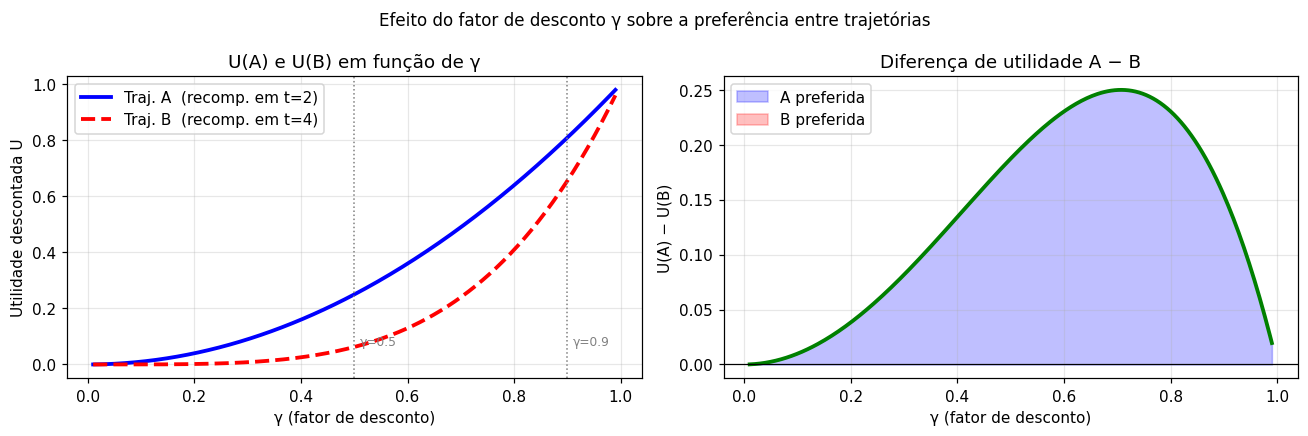

In [22]:
"""
04_desconto.py — Seção 3: Fator de desconto γ
Calcula a utilidade descontada das Trajetórias A e B do texto
para vários valores de γ e plota as curvas comparativas.

Trajetória A (curta):  r₀=0, r₁=0, r₂=+1
Trajetória B (longa):  r₀=0, r₁=0, r₂=0, r₃=0, r₄=+1
"""
import numpy as np
import matplotlib.pyplot as plt

def U(recompensas, gamma):
    """Utilidade descontada: U = Σ γ^t · r_t"""
    return sum(gamma ** t * r for t, r in enumerate(recompensas))

TRAJ_A = [0, 0, +1]         # recompensa em t=2
TRAJ_B = [0, 0, 0, 0, +1]   # recompensa em t=4

# ── Tabela de valores pontuais ────────────────────────────────
print("=" * 52)
print("  Fator de Desconto γ — Trajetórias A e B")
print("=" * 52)
print(f"\n  Trajetória A: {TRAJ_A}  (recompensa em t=2)")
print(f"  Trajetória B: {TRAJ_B}  (recompensa em t=4)\n")
print(f"  {'γ':>5}  {'U(A)':>8}  {'U(B)':>8}  {'A melhor?':>10}")
print("  " + "─" * 38)
for g in [0.10, 0.50, 0.90, 0.99]:
    ua = U(TRAJ_A, g)
    ub = U(TRAJ_B, g)
    print(f"  {g:>5.2f}  {ua:>8.4f}  {ub:>8.4f}  {'Sim' if ua > ub else 'Não':>10}")

print("\n  Interpretação:")
print("    γ baixo → agente impaciente → prefere fortemente A")
print("    γ alto  → agente paciente   → A e B ficam próximas")

# ── Gráfico ───────────────────────────────────────────────────
gammas = np.linspace(0.01, 0.99, 300)
UA = [U(TRAJ_A, g) for g in gammas]
UB = [U(TRAJ_B, g) for g in gammas]
diff = np.array(UA) - np.array(UB)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(gammas, UA, 'b-',  lw=2.5, label='Traj. A  (recomp. em t=2)')
ax.plot(gammas, UB, 'r--', lw=2.5, label='Traj. B  (recomp. em t=4)')
for g_mark in [0.5, 0.9]:
    ax.axvline(g_mark, color='gray', ls=':', lw=1)
    ax.text(g_mark + 0.01, 0.07, f'γ={g_mark}', fontsize=8, color='gray')
ax.set_xlabel('γ (fator de desconto)')
ax.set_ylabel('Utilidade descontada U')
ax.set_title('U(A) e U(B) em função de γ')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(gammas, diff, 'g-', lw=2.5)
ax2.axhline(0, color='k', lw=0.8)
ax2.fill_between(gammas, diff, 0,
                 where=(diff > 0), alpha=0.25, color='blue',  label='A preferida')
ax2.fill_between(gammas, diff, 0,
                 where=(diff < 0), alpha=0.25, color='red',   label='B preferida')
ax2.set_xlabel('γ (fator de desconto)')
ax2.set_ylabel('U(A) − U(B)')
ax2.set_title('Diferença de utilidade A − B')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Efeito do fator de desconto γ sobre a preferência entre trajetórias',
             fontsize=11)
plt.tight_layout()
plt.savefig('./04_desconto.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 4 — Aprendizado por Diferença Temporal (TD)
**Conceito:** erro TD δ, bootstrap, MC vs TD(0).  
Cadeia linear s1→s2→s3→s4 — mostra timing das atualizações.


  Erro TD(0) — exemplo passo a passo

  Estado atual: s2  →  próximo: s3
  V(s2) = 0.6   V(s3) = 0.9   r = 0.0

  δ = r + γ·V(s3) − V(s2)
    = 0.0 + 1.0×0.9 − 0.6 = +0.30

  V(s2) ← 0.6 + α·δ = 0.6 + 0.1×0.30 = 0.6300

  δ > 0: transição foi melhor do que o esperado.

  Valores após 150 episódios (V* = 1.0 para todos):
  Estado      V_MC      V_TD      V*
  ──────────────────────────────────
      s1    1.0000    1.0000     1.0
      s2    1.0000    1.0000     1.0
      s3    1.0000    1.0000     1.0


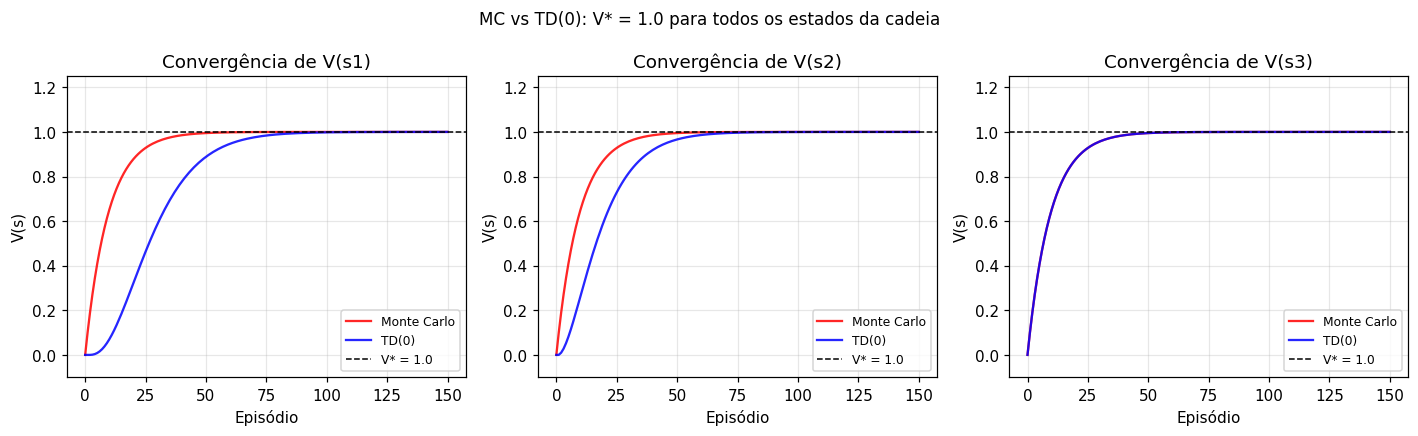

In [23]:
"""
05_erro_td.py — Seção 4: Erro de Diferença Temporal
Cadeia linear determinística: s1 → s2 → s3 → s4 (terminal, r=+1).
Compara MC (atualiza só ao fim do episódio) com TD(0) (atualiza
a cada passo). Mostra o cálculo do erro δ e plota a convergência.
"""
import numpy as np
import matplotlib.pyplot as plt

CADEIA   = ['s1', 's2', 's3']
TERMINAL = 's4'
PROX     = {'s1': 's2', 's2': 's3', 's3': TERMINAL}
ALPHA, GAMMA = 0.1, 1.0

def episodio():
    """Retorna a trajetória completa (sempre a mesma nesta cadeia)."""
    traj = ['s1']
    s = 's1'
    while s != TERMINAL:
        s = PROX[s]
        traj.append(s)
    return traj   # ['s1','s2','s3','s4']

# ── Exemplo numérico de um passo TD ──────────────────────────
print("=" * 55)
print("  Erro TD(0) — exemplo passo a passo")
print("=" * 55)
V_ex = {'s1': 0.3, 's2': 0.6, 's3': 0.9}
s_ex, s2_ex = 's2', 's3'
r_ex  = 0.0  # recompensa intermediária (só terminal tem r=+1)
delta = r_ex + GAMMA * V_ex[s2_ex] - V_ex[s_ex]
print(f"\n  Estado atual: {s_ex}  →  próximo: {s2_ex}")
print(f"  V({s_ex}) = {V_ex[s_ex]:.1f}   V({s2_ex}) = {V_ex[s2_ex]:.1f}   r = {r_ex:.1f}")
print(f"\n  δ = r + γ·V({s2_ex}) − V({s_ex})")
print(f"    = {r_ex:.1f} + {GAMMA}×{V_ex[s2_ex]:.1f} − {V_ex[s_ex]:.1f} = {delta:+.2f}")
print(f"\n  V({s_ex}) ← {V_ex[s_ex]:.1f} + α·δ = "
      f"{V_ex[s_ex]:.1f} + {ALPHA}×{delta:.2f} = "
      f"{V_ex[s_ex] + ALPHA*delta:.4f}")
sinal = "melhor" if delta > 0 else "pior" if delta < 0 else "igual"
print(f"\n  δ {'> 0' if delta > 0 else '< 0' if delta < 0 else '= 0'}: "
      f"transição foi {sinal} do que o esperado.")

# ── Treinamento: MC vs TD ─────────────────────────────────────
def treinar_mc(n_ep):
    V = {s: 0.0 for s in CADEIA}
    hist = {s: [0.0] for s in CADEIA}
    for _ in range(n_ep):
        traj = episodio()
        # MC: retorno real G calculado de trás para frente
        G = 0.0
        for i in range(len(traj) - 2, -1, -1):
            r = 1.0 if traj[i + 1] == TERMINAL else 0.0
            G = r + GAMMA * G
            s = traj[i]
            V[s] += ALPHA * (G - V[s])   # atualiza APÓS o episódio completo
        for s in CADEIA:
            hist[s].append(V[s])
    return hist

def treinar_td(n_ep):
    V = {s: 0.0 for s in CADEIA}
    hist = {s: [0.0] for s in CADEIA}
    for _ in range(n_ep):
        s = 's1'
        while s != TERMINAL:
            s2    = PROX[s]
            r     = 1.0 if s2 == TERMINAL else 0.0
            V_s2  = V.get(s2, 0.0)
            delta = r + GAMMA * V_s2 - V[s]
            V[s] += ALPHA * delta          # atualiza A CADA PASSO
            s = s2
        for s in CADEIA:
            hist[s].append(V[s])
    return hist

N_EP = 150
hist_mc = treinar_mc(N_EP)
hist_td = treinar_td(N_EP)

print(f"\n  Valores após {N_EP} episódios (V* = 1.0 para todos):")
print(f"  {'Estado':>6}  {'V_MC':>8}  {'V_TD':>8}  {'V*':>6}")
print("  " + "─" * 34)
for s in CADEIA:
    print(f"  {s:>6}  {hist_mc[s][-1]:>8.4f}  {hist_td[s][-1]:>8.4f}  {'1.0':>6}")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, s in enumerate(CADEIA):
    ax = axes[i]
    ax.plot(hist_mc[s], 'r-',  lw=1.5, alpha=0.85, label='Monte Carlo')
    ax.plot(hist_td[s], 'b-',  lw=1.5, alpha=0.85, label='TD(0)')
    ax.axhline(1.0, color='k', ls='--', lw=1, label='V* = 1.0')
    ax.set_title(f'Convergência de V({s})')
    ax.set_xlabel('Episódio'); ax.set_ylabel('V(s)')
    ax.set_ylim(-0.1, 1.25); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('MC vs TD(0): V* = 1.0 para todos os estados da cadeia', fontsize=11)
plt.tight_layout()
plt.savefig('./05_erro_td.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 5a — Q-learning Tabular
**Conceito:** regra de atualização Q-learning, política ótima, curva de aprendizado.  
Mundo Grade 4×3 com transições estocásticas.


  Q-learning Tabular — Mundo Grade 4×3

  Política aprendida:
  lin3    →     →     →    [+1] 
  lin2    ↑     ██    ↑    [-1] 
  lin1    ↑     ←     ←     ←   

  Tabela Q (amostra de estados, melhor ação destacada):
    Estado        N        S        L        O  Melhor
  ────────────────────────────────────────────────────
    (1, 1)   0.3591   0.2808   0.2620   0.3048  N
    (1, 2)   0.4785   0.3581   0.4219   0.3940  N
    (1, 3)   0.5237   0.4550   0.5667   0.4952  L
    (3, 1)   0.2026   0.2046   0.1233   0.2537  O
    (3, 2)   0.4761  -0.0217  -0.9408   0.1005  N
    (3, 3)   0.5858   0.3575   0.9263   0.5657  L


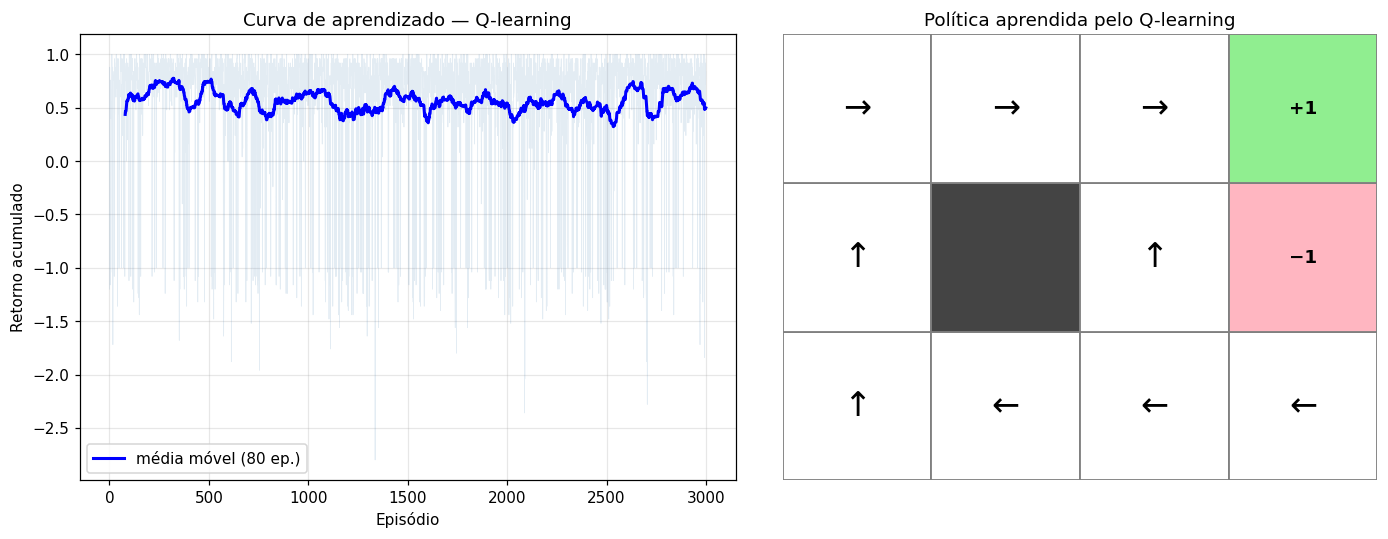

In [24]:
"""
06_qlearning_tabular.py — Seção 5: Q-learning tabular
Mundo Grade 4×3 com transições estocásticas.
Treina Q-learning e exibe:
  • Curva de aprendizado (retorno por episódio)
  • Tabela Q final (linhas = estados, colunas = ações)
  • Política ótima derivada com setas sobre a grade
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Mundo Grade 4×3 ──────────────────────────────────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})
NAO_T    = [s for s in ESTADOS if s not in ((4, 3), (4, 2))]
T_POS, T_NEG = (4, 3), (4, 2)
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}
PERP     = {'N': ('O', 'L'), 'S': ('L', 'O'), 'L': ('N', 'S'), 'O': ('S', 'N')}

def mover(s, a):
    c, r = s; dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s

def amostrar(s, a):
    ae, ad = PERP[a]
    return random.choices(
        [mover(s, a), mover(s, ae), mover(s, ad)],
        weights=[0.8, 0.1, 0.1])[0]

def recomp(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

# ── Q-learning ────────────────────────────────────────────────
def qlearning(n_ep=3000, alpha=0.3, gamma=0.9, eps=0.2, seed=0):
    random.seed(seed)
    Q = defaultdict(float)
    retornos = []
    for _ in range(n_ep):
        s = random.choice(NAO_T)
        G = 0.0
        for _ in range(150):
            if s in (T_POS, T_NEG): break
            a = (random.choice(ACOES) if random.random() < eps
                 else max(ACOES, key=lambda x: Q[(s, x)]))
            s2 = amostrar(s, a)
            r  = recomp(s2)
            G += r
            max_q2 = max(Q[(s2, x)] for x in ACOES)
            delta  = r + gamma * max_q2 - Q[(s, a)]
            Q[(s, a)] += alpha * delta
            s = s2
        retornos.append(G)
    return Q, retornos

Q, retornos = qlearning()

# ── Derivar política ──────────────────────────────────────────
SETA     = {'N': '↑', 'S': '↓', 'L': '→', 'O': '←'}
politica = {s: max(ACOES, key=lambda a: Q[(s, a)]) for s in NAO_T}

print("=" * 56)
print("  Q-learning Tabular — Mundo Grade 4×3")
print("=" * 56)
print("\n  Política aprendida:")
for row in range(3, 0, -1):
    linha = f"  lin{row}  "
    for col in range(1, 5):
        s = (col, row)
        if   s == (2, 2):  linha += "  ██  "
        elif s == T_POS:   linha += " [+1] "
        elif s == T_NEG:   linha += " [-1] "
        else:              linha += f"  {SETA[politica[s]]}   "
    print(linha)

print("\n  Tabela Q (amostra de estados, melhor ação destacada):")
print(f"  {'Estado':>8}  {'N':>7}  {'S':>7}  {'L':>7}  {'O':>7}  Melhor")
print("  " + "─" * 52)
for s in [(1,1),(1,2),(1,3),(3,1),(3,2),(3,3)]:
    vals = {a: Q[(s, a)] for a in ACOES}
    mel  = max(ACOES, key=lambda a: vals[a])
    print(f"  {str(s):>8}  " +
          "  ".join(f"{vals[a]:>7.4f}" for a in ACOES) +
          f"  {mel}")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva de aprendizado
ax = axes[0]
w = 80
ma = np.convolve(retornos, np.ones(w) / w, mode='valid')
ax.plot(retornos, alpha=0.15, color='steelblue', lw=0.5)
ax.plot(range(w - 1, len(retornos)), ma, color='blue', lw=2,
        label=f'média móvel ({w} ep.)')
ax.set_xlabel('Episódio'); ax.set_ylabel('Retorno acumulado')
ax.set_title('Curva de aprendizado — Q-learning')
ax.legend(); ax.grid(True, alpha=0.3)

# Grade com política
ax2 = axes[1]
ax2.set_xlim(0.5, 4.5); ax2.set_ylim(0.5, 3.5)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Política aprendida pelo Q-learning')
for col in range(1, 5):
    for row in range(1, 4):
        s = (col, row)
        fc = ('#444'    if s == (2, 2)  else
              '#90EE90' if s == T_POS   else
              '#FFB6C1' if s == T_NEG   else 'white')
        ax2.add_patch(plt.Rectangle((col - .5, row - .5), 1, 1,
                                    ec='gray', fc=fc, lw=1.2))
        if   s == T_POS:  ax2.text(col, row, '+1', ha='center', va='center',
                                   fontsize=12, fontweight='bold')
        elif s == T_NEG:  ax2.text(col, row, '−1', ha='center', va='center',
                                   fontsize=12, fontweight='bold')
        elif s != (2, 2): ax2.text(col, row, SETA[politica[s]],
                                   ha='center', va='center', fontsize=22)

plt.tight_layout()
plt.savefig('./06_qlearning_tabular.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 5b — Propagação de Valor
**Conceito:** o valor se propaga do terminal para estados distantes ao longo dos episódios.  
Cadeia linear determinística — convergência estado a estado.


  Propagação de valor — cadeia s1→s2→s3→s4(+1)

  α = 0.5   γ = 0.9

   Estado     Q_final        Q*      Erro
  ──────────────────────────────────────
       s1      0.8100    0.7290    0.0810
       s2      0.9000    0.8100    0.0900
       s3      1.0000    0.9000    0.1000

  Observação:
    Ep.  1: apenas Q(s3) recebe sinal positivo (vizinho do terminal)
    Ep.  2: Q(s2) começa a subir (herda o valor de s3)
    Ep. 3+: Q(s1) finalmente sobe (herda o valor de s2)
    → Estados distantes do terminal precisam de mais episódios.


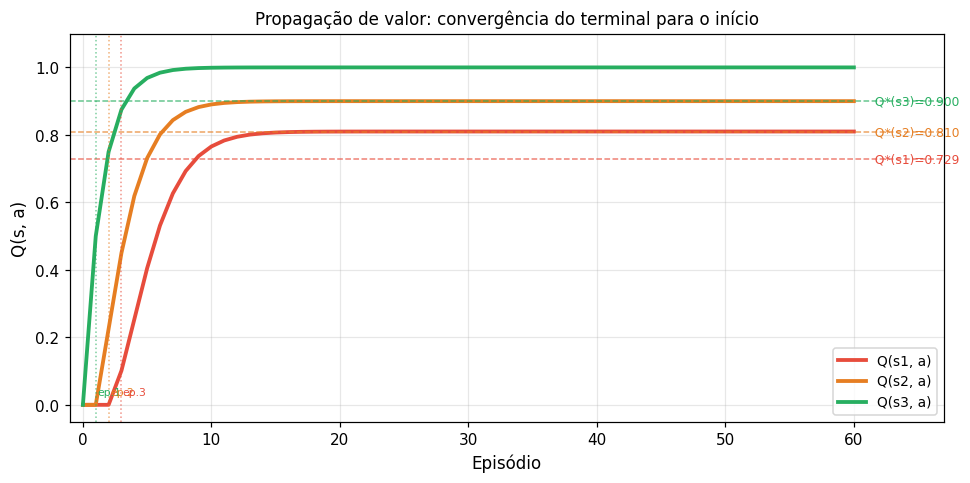

In [25]:
"""
07_propagacao_valor.py — Seção 5: Propagação de valor
Cadeia linear determinística: s1 → s2 → s3 → s4 (terminal, r=+1).
Mostra que o valor se propaga a partir do terminal: s3 converge
primeiro, depois s2, depois s1 — exatamente como descrito no texto.
"""
import matplotlib.pyplot as plt
import numpy as np

CADEIA   = ['s1', 's2', 's3']
TERMINAL = 's4'
PROX     = {'s1': 's2', 's2': 's3', 's3': TERMINAL}
ALPHA    = 0.5
GAMMA    = 0.9

# Valores ótimos: Q*(sk) = γ^(distância ao terminal)
Q_STAR = {
    's3': GAMMA ** 1,   # 1 passo do terminal
    's2': GAMMA ** 2,   # 2 passos
    's1': GAMMA ** 3,   # 3 passos
}

def treinar(n_ep):
    Q = {s: 0.0 for s in CADEIA}
    hist = {s: [0.0] for s in CADEIA}
    for ep in range(n_ep):
        s = 's1'
        while s != TERMINAL:
            s2    = PROX[s]
            r     = 1.0 if s2 == TERMINAL else 0.0
            Q_s2  = Q.get(s2, 0.0)
            delta = r + GAMMA * Q_s2 - Q[s]
            Q[s] += ALPHA * delta
            s = s2
        for estado in CADEIA:
            hist[estado].append(Q[estado])
    return Q, hist

Q_final, hist = treinar(n_ep=60)

print("=" * 55)
print("  Propagação de valor — cadeia s1→s2→s3→s4(+1)")
print("=" * 55)
print(f"\n  α = {ALPHA}   γ = {GAMMA}\n")
print(f"  {'Estado':>7}  {'Q_final':>10}  {'Q*':>8}  {'Erro':>8}")
print("  " + "─" * 38)
for s in CADEIA:
    erro = abs(Q_final[s] - Q_STAR[s])
    print(f"  {s:>7}  {Q_final[s]:>10.4f}  {Q_STAR[s]:>8.4f}  {erro:>8.4f}")

print("\n  Observação:")
print("    Ep.  1: apenas Q(s3) recebe sinal positivo (vizinho do terminal)")
print("    Ep.  2: Q(s2) começa a subir (herda o valor de s3)")
print("    Ep. 3+: Q(s1) finalmente sobe (herda o valor de s2)")
print("    → Estados distantes do terminal precisam de mais episódios.")

# ── Gráfico ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
CORES = {'s1': '#e74c3c', 's2': '#e67e22', 's3': '#27ae60'}

for s in CADEIA:
    ax.plot(hist[s], color=CORES[s], lw=2.5, label=f'Q({s}, a)')
    ax.axhline(Q_STAR[s], color=CORES[s], ls='--', lw=1, alpha=0.7)
    # Anotação do valor ótimo
    ax.text(len(hist['s1']) + 0.3, Q_STAR[s],
            f' Q*({s})={Q_STAR[s]:.3f}',
            fontsize=8, color=CORES[s], va='center')

# Marca os episódios onde cada estado "acorda"
ep_acorda = {'s3': 1, 's2': 2, 's1': 3}
for s, ep in ep_acorda.items():
    ax.axvline(ep, color=CORES[s], ls=':', lw=1, alpha=0.6)
    ax.text(ep + 0.1, 0.03, f'ep.{ep}', fontsize=7, color=CORES[s])

ax.set_xlabel('Episódio', fontsize=11)
ax.set_ylabel('Q(s, a)', fontsize=11)
ax.set_title('Propagação de valor: convergência do terminal para o início', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-1, len(hist['s1']) + 6)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('./07_propagacao_valor.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 6a — SARSA vs Q-learning
**Conceito:** off-policy vs on-policy, trajetórias rente ao penhasco vs seguras.  
Ambiente Cliff Walking — o exemplo clássico de Sutton & Barto.


  SARSA vs Q-learning — Cliff Walking

  Trajetória Q-learning (gulosa): 14 passos
  Trajetória SARSA     (gulosa): 101 passos

  Retorno médio (últimos 100 episódios):
    Q-learning: -63.0
    SARSA:      -31.1

  Interpretação:
    Q-learning aprende o caminho ótimo para um agente SEM exploração.
    SARSA aprende o caminho mais seguro dado que EXPLORA com ε=0.1.


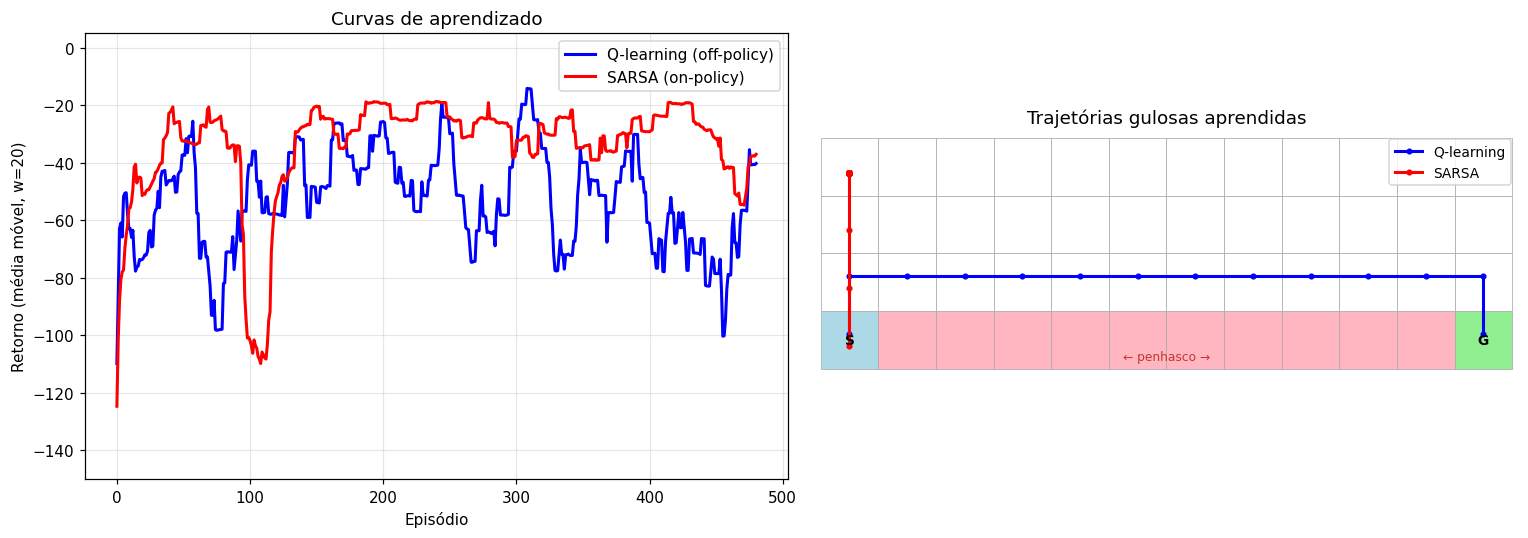

In [26]:
"""
08_sarsa_vs_qlearning.py — Seção 6: SARSA vs Q-learning
Ambiente Cliff Walking (Sutton & Barto):
  grade 4×12, início (0,0), objetivo (11,0),
  penhasco: (1,0)–(10,0) → penalidade −100, volta ao início.
Mostra que Q-learning aprende o caminho rente ao penhasco (off-policy)
enquanto SARSA aprende o caminho mais seguro (on-policy).
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Ambiente Cliff Walking ────────────────────────────────────
COLS, ROWS = 12, 4
INICIO     = (0, 0)
GOAL       = (11, 0)
CLIFF      = {(c, 0) for c in range(1, 11)}
ACOES      = ['N', 'S', 'L', 'O']
DELTA      = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}

def mover_cliff(s, a):
    c, r = s; dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    if 0 <= s2[0] < COLS and 0 <= s2[1] < ROWS:
        return s2
    return s

def passo(s, a):
    """Retorna (s', r) com lógica do penhasco."""
    s2 = mover_cliff(s, a)
    if s2 in CLIFF:
        return INICIO, -100.0   # cai: penalidade severa e volta ao início
    return s2, -1.0             # passo normal

def eps_greedy(Q, s, eps):
    return (random.choice(ACOES) if random.random() < eps
            else max(ACOES, key=lambda a: Q[(s, a)]))

# ── Q-learning (off-policy) ───────────────────────────────────
def treinar_ql(n_ep=500, alpha=0.5, gamma=1.0, eps=0.1, seed=42):
    random.seed(seed)
    Q = defaultdict(float)
    retornos = []
    for _ in range(n_ep):
        s, G = INICIO, 0
        for _ in range(500):
            if s == GOAL: break
            a = eps_greedy(Q, s, eps)
            s2, r = passo(s, a)
            G += r
            max_q2 = max(Q[(s2, x)] for x in ACOES)
            Q[(s, a)] += alpha * (r + gamma * max_q2 - Q[(s, a)])
            s = s2
        retornos.append(max(G, -500))
    return Q, retornos

# ── SARSA (on-policy) ─────────────────────────────────────────
def treinar_sarsa(n_ep=500, alpha=0.5, gamma=1.0, eps=0.1, seed=42):
    random.seed(seed)
    Q = defaultdict(float)
    retornos = []
    for _ in range(n_ep):
        s = INICIO
        a = eps_greedy(Q, s, eps)
        G = 0
        for _ in range(500):
            if s == GOAL: break
            s2, r = passo(s, a)
            G += r
            a2 = eps_greedy(Q, s2, eps)
            Q[(s, a)] += alpha * (r + gamma * Q[(s2, a2)] - Q[(s, a)])
            s, a = s2, a2
        retornos.append(max(G, -500))
    return Q, retornos

Q_ql,    ret_ql    = treinar_ql()
Q_sarsa, ret_sarsa = treinar_sarsa()

# ── Trajetória gulosa ─────────────────────────────────────────
def traj_gulosa(Q, max_p=100):
    s, traj = INICIO, [INICIO]
    for _ in range(max_p):
        if s == GOAL: break
        a = max(ACOES, key=lambda a: Q[(s, a)])
        s2, _ = passo(s, a)
        if s2 in CLIFF: s2 = INICIO
        traj.append(s2); s = s2
    return traj

tj_ql    = traj_gulosa(Q_ql)
tj_sarsa = traj_gulosa(Q_sarsa)

print("=" * 55)
print("  SARSA vs Q-learning — Cliff Walking")
print("=" * 55)
print(f"\n  Trajetória Q-learning (gulosa): {len(tj_ql)} passos")
print(f"  Trajetória SARSA     (gulosa): {len(tj_sarsa)} passos")
w = 100
print(f"\n  Retorno médio (últimos {w} episódios):")
print(f"    Q-learning: {np.mean(ret_ql[-w:]):.1f}")
print(f"    SARSA:      {np.mean(ret_sarsa[-w:]):.1f}")
print("\n  Interpretação:")
print("    Q-learning aprende o caminho ótimo para um agente SEM exploração.")
print("    SARSA aprende o caminho mais seguro dado que EXPLORA com ε=0.1.")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de aprendizado
ax = axes[0]
ww = 20
ax.plot(np.convolve(ret_ql,    np.ones(ww)/ww, mode='valid'),
        'b-', lw=2, label='Q-learning (off-policy)')
ax.plot(np.convolve(ret_sarsa, np.ones(ww)/ww, mode='valid'),
        'r-', lw=2, label='SARSA (on-policy)')
ax.set_xlabel('Episódio'); ax.set_ylabel(f'Retorno (média móvel, w={ww})')
ax.set_title('Curvas de aprendizado'); ax.set_ylim(-150, 5)
ax.legend(); ax.grid(True, alpha=0.3)

# Trajetórias sobre a grade
ax2 = axes[1]
for row in range(ROWS):
    for col in range(COLS):
        s = (col, row)
        fc = ('#FFB6C1' if s in CLIFF else
              '#ADD8E6' if s == INICIO else
              '#90EE90' if s == GOAL  else 'white')
        ax2.add_patch(plt.Rectangle((col - .5, row - .5), 1, 1,
                                    ec='#aaa', fc=fc, lw=0.5))
ax2.text(INICIO[0], INICIO[1], 'S', ha='center', va='center',
         fontsize=9, fontweight='bold')
ax2.text(GOAL[0],   GOAL[1],   'G', ha='center', va='center',
         fontsize=9, fontweight='bold')
ax2.text(5.5, -.35, '← penhasco →', ha='center', fontsize=8, color='#c0392b')

for traj, cor, lbl, dy in [(tj_ql, 'blue', 'Q-learning', +0.10),
                            (tj_sarsa, 'red', 'SARSA', -0.10)]:
    xs = [s[0] for s in traj]
    ys = [s[1] + dy for s in traj]
    ax2.plot(xs, ys, '-o', color=cor, ms=3, lw=2, label=lbl)

ax2.set_xlim(-0.6, 11.6); ax2.set_ylim(-0.7, 3.6)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Trajetórias gulosas aprendidas')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('./08_sarsa_vs_qlearning.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 6b — Estratégias de Exploração
**Conceito:** ε-greedy, softmax/Boltzmann e função de exploração f(u,n) = u + k/n.  
Tabelas de probabilidade e gráficos comparativos para o estado (1,1).


  Estratégias de Exploração — estado (1,1)

  Q-valores:  N=0.41  S=-0.12  L=0.28  O=-0.04
  Visitas:    N= 50   S=  3   L= 12   O=  1

  ── ε-greedy ─────────────────────────────────────────
      ε      P(N)      P(S)      P(L)      P(O)
   0.00    1.0000    0.0000    0.0000    0.0000
   0.05    0.9625    0.0125    0.0125    0.0125
   0.10    0.9250    0.0250    0.0250    0.0250
   0.30    0.7750    0.0750    0.0750    0.0750
   1.00    0.2500    0.2500    0.2500    0.2500

  ── Softmax (Boltzmann) ──────────────────────────────
      τ      P(N)      P(S)      P(L)      P(O)
   0.01    1.0000    0.0000    0.0000    0.0000
   0.10    0.7760    0.0039    0.2115    0.0086
   0.30    0.4896    0.0837    0.3174    0.1093
   1.00    0.3221    0.1896    0.2829    0.2054
   5.00    0.2640    0.2375    0.2572    0.2413

  ── Função de exploração  f(u,n) = u + k/n  (k=1.0) ──
   Ação    Q(s,a)    N(s,a)    f(Q,N)  Escolhida?
      N     0.410        50     0.430
      S    -0.120         3   

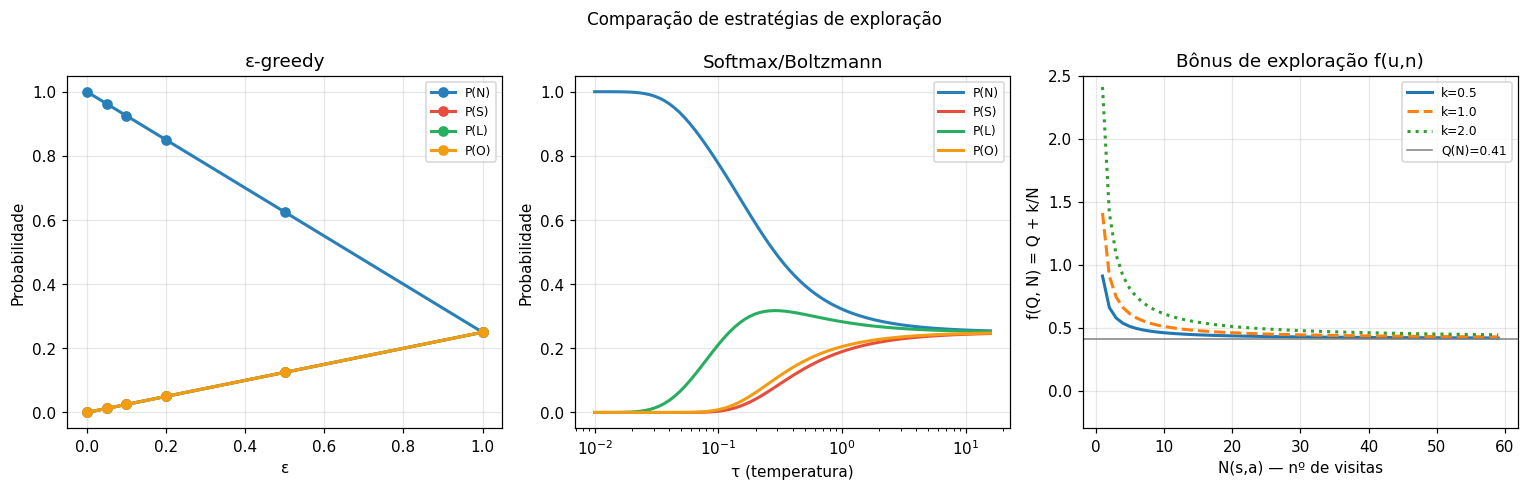

In [27]:
"""
09_estrategias_exploracao.py — Seção 6: Estratégias de exploração
Para o estado (1,1) com os Q-valores e contadores do texto,
compara três estratégias:
  (1) ε-greedy
  (2) Softmax/Boltzmann
  (3) Função de exploração  f(u, n) = u + k/n
"""
import numpy as np
import matplotlib.pyplot as plt

# ── Dados do exemplo do texto (estado (1,1)) ─────────────────
ACOES = ['N', 'S', 'L', 'O']
Q     = {'N':  0.41, 'S': -0.12, 'L':  0.28, 'O': -0.04}
N_vis = {'N':  50,   'S':  3,    'L':  12,    'O':  1}

# ── Estratégia 1: ε-greedy ────────────────────────────────────
def eps_greedy_probs(Q, eps):
    melhor = max(Q, key=Q.get)
    n = len(Q)
    return {a: (1 - eps + eps / n if a == melhor else eps / n) for a in Q}

# ── Estratégia 2: Softmax ─────────────────────────────────────
def softmax_probs(Q, tau):
    vals = np.array([Q[a] for a in ACOES])
    e    = np.exp(vals / tau)
    return {a: e[i] / e.sum() for i, a in enumerate(ACOES)}

# ── Estratégia 3: Função de exploração ───────────────────────
def funcao_exp(Q, N, k=1.0):
    f = {a: Q[a] + k / N[a] for a in ACOES}
    melhor = max(f, key=f.get)
    return {a: (1.0 if a == melhor else 0.0) for a in ACOES}, f

# ── Impressão das tabelas ─────────────────────────────────────
print("=" * 64)
print("  Estratégias de Exploração — estado (1,1)")
print("=" * 64)
print(f"\n  Q-valores:  N={Q['N']:.2f}  S={Q['S']:.2f}"
      f"  L={Q['L']:.2f}  O={Q['O']:.2f}")
print(f"  Visitas:    N={N_vis['N']:>3}   S={N_vis['S']:>3}"
      f"   L={N_vis['L']:>3}   O={N_vis['O']:>3}\n")

print("  ── ε-greedy ─────────────────────────────────────────")
print(f"  {'ε':>5}  {'P(N)':>8}  {'P(S)':>8}  {'P(L)':>8}  {'P(O)':>8}")
for eps in [0.0, 0.05, 0.10, 0.30, 1.00]:
    p = eps_greedy_probs(Q, eps)
    print(f"  {eps:>5.2f}  " + "  ".join(f"{p[a]:>8.4f}" for a in ACOES))

print()
print("  ── Softmax (Boltzmann) ──────────────────────────────")
print(f"  {'τ':>5}  {'P(N)':>8}  {'P(S)':>8}  {'P(L)':>8}  {'P(O)':>8}")
for tau in [0.01, 0.10, 0.30, 1.00, 5.00]:
    p = softmax_probs(Q, tau)
    print(f"  {tau:>5.2f}  " + "  ".join(f"{p[a]:>8.4f}" for a in ACOES))

print()
print("  ── Função de exploração  f(u,n) = u + k/n  (k=1.0) ──")
probs_fe, f_vals = funcao_exp(Q, N_vis, k=1.0)
print(f"  {'Ação':>5}  {'Q(s,a)':>8}  {'N(s,a)':>8}  {'f(Q,N)':>8}  Escolhida?")
for a in ACOES:
    flag = "  ← SIM" if probs_fe[a] == 1.0 else ""
    print(f"  {a:>5}  {Q[a]:>8.3f}  {N_vis[a]:>8}  {f_vals[a]:>8.3f}{flag}")

print("\n  → Oeste tem Q ruim, mas foi visitada apenas 1 vez:")
print("    o bônus de exploração eleva f(O) = −0.04 + 1.0/1 = 0.96")
print("    (acima de N com f(N) = 0.41 + 1.0/50 ≈ 0.43)")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
CORES = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12']

# ε-greedy
ax = axes[0]
eps_range = [0.0, 0.05, 0.10, 0.20, 0.50, 1.00]
for a, c in zip(ACOES, CORES):
    ax.plot(eps_range, [eps_greedy_probs(Q, e)[a] for e in eps_range],
            'o-', color=c, lw=2, label=f'P({a})')
ax.set_xlabel('ε'); ax.set_ylabel('Probabilidade')
ax.set_title('ε-greedy'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Softmax
ax2 = axes[1]
taus = np.logspace(-2, 1.2, 80)
for a, c in zip(ACOES, CORES):
    ax2.semilogx(taus, [softmax_probs(Q, t)[a] for t in taus],
                 '-', color=c, lw=2, label=f'P({a})')
ax2.set_xlabel('τ (temperatura)'); ax2.set_ylabel('Probabilidade')
ax2.set_title('Softmax/Boltzmann'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Bônus f(u,n) em função de N(s,a)
ax3 = axes[2]
ns = np.arange(1, 60)
for k, ls in zip([0.5, 1.0, 2.0], ['-', '--', ':']):
    ax3.plot(ns, Q['N'] + k / ns, lw=2, ls=ls, label=f'k={k}')
ax3.axhline(Q['N'], color='gray', lw=1, label=f'Q(N)={Q["N"]}')
ax3.set_xlabel('N(s,a) — nº de visitas')
ax3.set_ylabel('f(Q, N) = Q + k/N')
ax3.set_title('Bônus de exploração f(u,n)')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3); ax3.set_ylim(-0.3, 2.5)

plt.suptitle('Comparação de estratégias de exploração', fontsize=11)
plt.tight_layout()
plt.savefig('./09_estrategias_exploracao.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 6c — Regret Acumulado
**Conceito:** quantidade de ações subótimas ao longo do treinamento.  
ε-greedy distribui exploração uniformemente; f(u,n) concentra onde há incerteza.


  Regret acumulado: ε-greedy vs f(u,n)

  Após 12000 passos:
    ε-greedy  (ε=0.1): 938 ações subótimas
    f(u,n)    (k=1.0): 141  ações subótimas

  Redução de regret com f(u,n): 85.0%

  Razão: f(u,n) concentra a exploração onde a incerteza é maior
  (estados pouco visitados). ε-greedy distribui uniformemente,
  incluindo estados já bem conhecidos — desperdício de exploração.


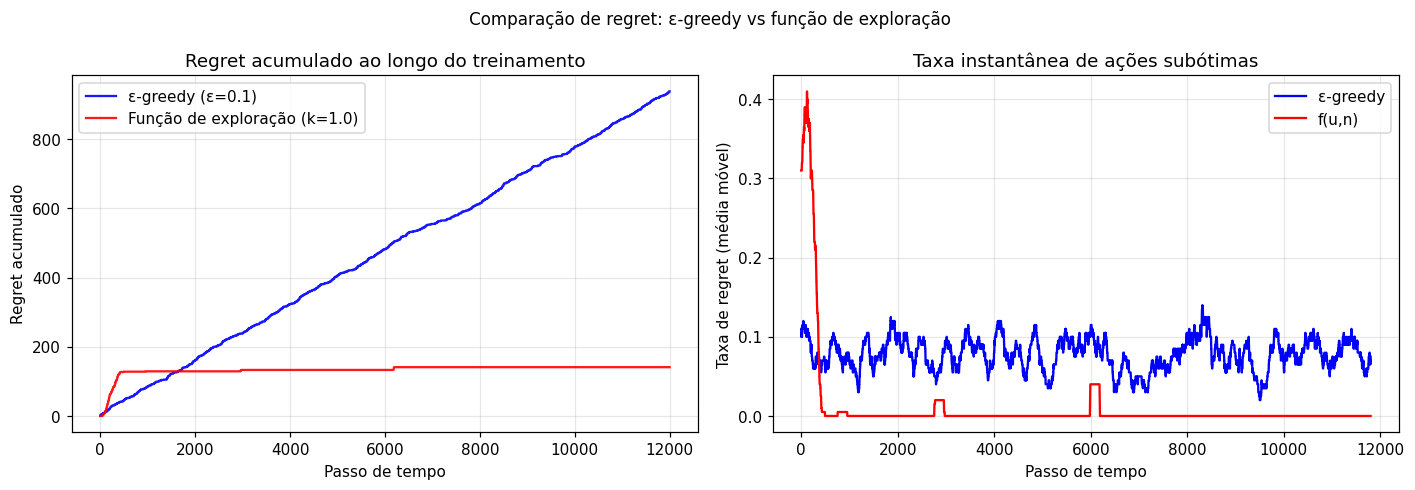

In [28]:
"""
10_regret_acumulado.py — Seção 6: Regret acumulado
Compara ε-greedy (ε fixo) com a função de exploração f(u,n) = u + k/n
no Mundo Grade. O regret conta passos em que a ação escolhida
não foi a melhor ação disponível segundo Q atual.
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Mundo Grade 4×3 ──────────────────────────────────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})
NAO_T    = [s for s in ESTADOS if s not in ((4, 3), (4, 2))]
T_POS, T_NEG = (4, 3), (4, 2)
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}
PERP     = {'N': ('O', 'L'), 'S': ('L', 'O'), 'L': ('N', 'S'), 'O': ('S', 'N')}

def mover(s, a):
    c, r = s; dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s

def amostrar(s, a):
    ae, ad = PERP[a]
    return random.choices([mover(s,a), mover(s,ae), mover(s,ad)],
                          weights=[0.8, 0.1, 0.1])[0]

def recomp(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

# ── Treinamento com medição de regret ─────────────────────────
def treinar(estrategia, n_passos=12000,
            alpha=0.3, gamma=0.9, eps=0.1, k=1.0, seed=0):
    random.seed(seed)
    Q  = defaultdict(float)
    N  = defaultdict(int)
    regret_serie = []
    regret_acum  = 0
    passo = 0

    while passo < n_passos:
        s = random.choice(NAO_T)
        for _ in range(40):
            if s in (T_POS, T_NEG) or passo >= n_passos:
                break
            # Escolha de ação segundo a estratégia
            if estrategia == 'eps_greedy':
                a = (random.choice(ACOES) if random.random() < eps
                     else max(ACOES, key=lambda x: Q[(s, x)]))
            else:   # funcao_exp
                a = max(ACOES, key=lambda x: Q[(s, x)] + k / (N[(s, x)] + 1))

            # Regret: ação não foi a melhor disponível?
            melhor_a = max(ACOES, key=lambda x: Q[(s, x)])
            if a != melhor_a:
                regret_acum += 1
            regret_serie.append(regret_acum)

            N[(s, a)] += 1
            s2  = amostrar(s, a)
            r   = recomp(s2)
            mq2 = max(Q[(s2, x)] for x in ACOES)
            Q[(s, a)] += alpha * (r + gamma * mq2 - Q[(s, a)])
            s = s2; passo += 1

    return regret_serie[:n_passos], Q

reg_eps, Q_eps = treinar('eps_greedy', seed=7)
reg_fe,  Q_fe  = treinar('funcao_exp', seed=7)

# ── Impressão ─────────────────────────────────────────────────
print("=" * 55)
print("  Regret acumulado: ε-greedy vs f(u,n)")
print("=" * 55)
print(f"\n  Após {len(reg_eps)} passos:")
print(f"    ε-greedy  (ε=0.1): {reg_eps[-1]} ações subótimas")
print(f"    f(u,n)    (k=1.0): {reg_fe[-1]}  ações subótimas")

reducao = (reg_eps[-1] - reg_fe[-1]) / reg_eps[-1] * 100
print(f"\n  Redução de regret com f(u,n): {reducao:.1f}%")
print("\n  Razão: f(u,n) concentra a exploração onde a incerteza é maior")
print("  (estados pouco visitados). ε-greedy distribui uniformemente,")
print("  incluindo estados já bem conhecidos — desperdício de exploração.")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(reg_eps, 'b-', lw=1.5, alpha=0.9, label='ε-greedy (ε=0.1)')
ax.plot(reg_fe,  'r-', lw=1.5, alpha=0.9, label='Função de exploração (k=1.0)')
ax.set_xlabel('Passo de tempo')
ax.set_ylabel('Regret acumulado')
ax.set_title('Regret acumulado ao longo do treinamento')
ax.legend(); ax.grid(True, alpha=0.3)

# Taxa instantânea (janela deslizante)
ax2 = axes[1]
w = 200
eps_d = np.diff(reg_eps)
fe_d  = np.diff(reg_fe)
ma_eps = np.convolve(eps_d, np.ones(w)/w, mode='valid')
ma_fe  = np.convolve(fe_d,  np.ones(w)/w, mode='valid')
ax2.plot(ma_eps, 'b-', lw=1.5, label='ε-greedy')
ax2.plot(ma_fe,  'r-', lw=1.5, label='f(u,n)')
ax2.set_xlabel('Passo de tempo')
ax2.set_ylabel('Taxa de regret (média móvel)')
ax2.set_title('Taxa instantânea de ações subótimas')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Comparação de regret: ε-greedy vs função de exploração', fontsize=11)
plt.tight_layout()
plt.savefig('./10_regret_acumulado.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 7a — Engenharia de Features
**Conceito:** features de estado, expansão em blocos para estado-ação,  
e como uma representação pobre provoca generalização indevida.


  Features no Mundo Grade — Seção 7

  ── Features de ESTADO f(s) ──────────────────────────────
    Estado      dist_obj   prox_perigo      alin_col      alin_lin
  ──────────────────────────────────────────────────────────────
    (1, 1)        0.8333        0.2000        0.0000        0.0000
    (2, 1)        0.6667        0.2500        0.0000        0.0000
    (3, 1)        0.5000        0.3333        0.0000        0.0000
    (4, 1)        0.3333        0.5000        1.0000        0.0000
    (1, 2)        0.6667        0.2500        0.0000        0.0000
    (3, 2)        0.3333        0.5000        0.0000        0.0000
    (3, 3)        0.1667        0.3333        0.0000        1.0000
    (4, 3)        0.0000        0.5000        1.0000        1.0000
    (4, 2)        0.1667        1.0000        1.0000        0.0000

  ── Features de ESTADO-AÇÃO f(s,a)  para s=(3, 2) ───────────
  (apenas o bloco da ação selecionada é não-zero)

  Ação   vetor f(s,a) [truncado p/ legibilidade]
  ──

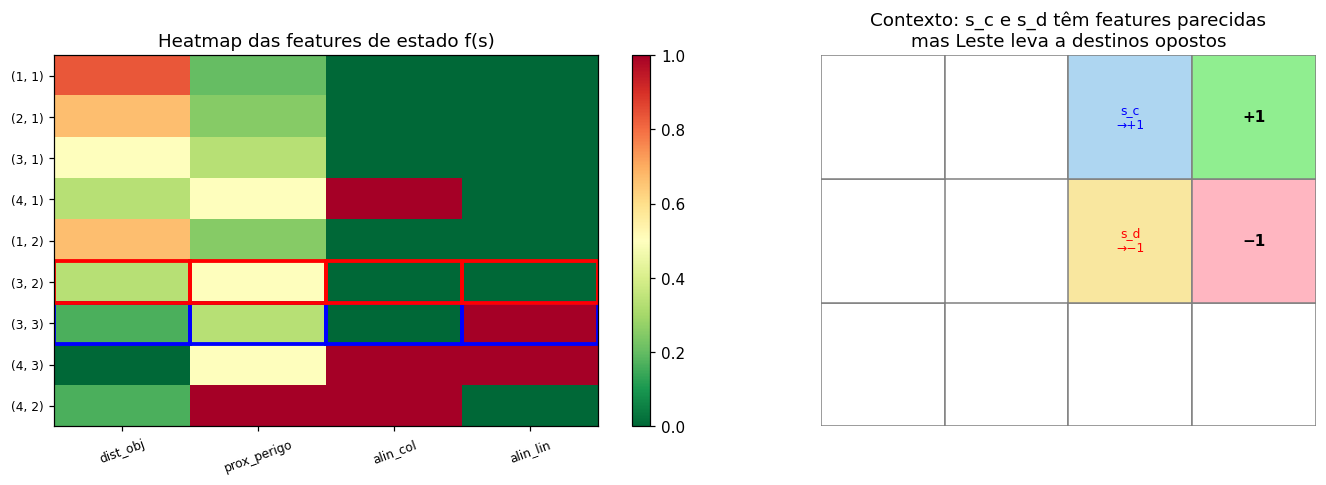

In [29]:
"""
11_features_mundograde.py — Seção 7: Engenharia de features
Define features para o Mundo Grade e demonstra:
  • Cálculo de f(s) para diferentes estados
  • Expansão de features de estado → features de estado-ação (blocos)
  • Por que features só de estado não bastam para distinguir Q(s,a)
"""
import numpy as np
import matplotlib.pyplot as plt

T_POS = (4, 3)
T_NEG = (4, 2)

# ── Definição das features de estado ─────────────────────────
def dist_manhattan(s, destino):
    return abs(s[0] - destino[0]) + abs(s[1] - destino[1])

D_MAX = 6.0   # máxima distância Manhattan no Mundo Grade 4×3

def f1_dist_obj(s):
    """Distância normalizada ao terminal positivo [0,1]."""
    return dist_manhattan(s, T_POS) / D_MAX

def f2_prox_perigo(s):
    """Proximidade do terminal negativo: 1/(1+d), mais alto = mais perto."""
    return 1.0 / (1 + dist_manhattan(s, T_NEG))

def f3_alinhado_col(s):
    """1 se mesma coluna que o objetivo."""
    return 1.0 if s[0] == T_POS[0] else 0.0

def f4_alinhado_lin(s):
    """1 se mesma linha que o objetivo."""
    return 1.0 if s[1] == T_POS[1] else 0.0

FEATURES     = [f1_dist_obj, f2_prox_perigo, f3_alinhado_col, f4_alinhado_lin]
NOMES_FEAT   = ['dist_obj', 'prox_perigo', 'alin_col', 'alin_lin']
ACOES        = ['N', 'S', 'L', 'O']
N_F          = len(FEATURES)

def vetor_estado(s):
    return np.array([f(s) for f in FEATURES])

def vetor_estado_acao(s, a):
    """
    Expande features de estado para features de estado-ação.
    Vetor de tamanho N_F × |A| com um bloco por ação.
    Apenas o bloco da ação escolhida é não-zero.
    """
    idx = ACOES.index(a)
    v   = np.zeros(N_F * len(ACOES))
    v[idx * N_F : (idx + 1) * N_F] = vetor_estado(s)
    return v

# ── Features de estado ────────────────────────────────────────
print("=" * 66)
print("  Features no Mundo Grade — Seção 7")
print("=" * 66)
print("\n  ── Features de ESTADO f(s) ──────────────────────────────")
print(f"  {'Estado':>8}  " + "  ".join(f"{n:>12}" for n in NOMES_FEAT))
print("  " + "─" * 62)
estados_demo = [(1,1), (2,1), (3,1), (4,1), (1,2), (3,2), (3,3), (4,3), (4,2)]
for s in estados_demo:
    vals = vetor_estado(s)
    print(f"  {str(s):>8}  " + "  ".join(f"{v:>12.4f}" for v in vals))

# ── Features de estado-ação ───────────────────────────────────
s_ex = (3, 2)
print(f"\n  ── Features de ESTADO-AÇÃO f(s,a)  para s={s_ex} ───────────")
print("  (apenas o bloco da ação selecionada é não-zero)")
nomes_bloco = [f"{a}_{n}" for a in ACOES for n in NOMES_FEAT]
print(f"\n  {'Ação':>4}   vetor f(s,a) [truncado p/ legibilidade]")
print("  " + "─" * 62)
for a in ACOES:
    v     = vetor_estado_acao(s_ex, a)
    bloco = v[ACOES.index(a)*N_F : (ACOES.index(a)+1)*N_F]
    zeros = np.zeros(N_F)
    blocos_str = ' | '.join(
        f"[{', '.join(f'{x:.3f}' for x in (bloco if i == ACOES.index(a) else zeros))}]"
        for i in range(len(ACOES)))
    print(f"  {a:>4}   {blocos_str}")

# ── Limite da representação: estados perigosamente similares ──
print("\n  ── Representação insuficiente: mesmas features, contextos opostos ─")
s_c = (3, 3)   # próximo do objetivo, ação Leste → terminal +1
s_d = (3, 2)   # mesma coluna,        ação Leste → terminal -1
print(f"\n  s_c = {s_c}:  f(s_c) = {np.round(vetor_estado(s_c), 4)}")
print(f"  s_d = {s_d}:  f(s_d) = {np.round(vetor_estado(s_d), 4)}")
dist = np.linalg.norm(vetor_estado(s_c) - vetor_estado(s_d))
print(f"  ‖f(s_c) − f(s_d)‖ = {dist:.4f}  (vetores parecidos)")
print(f"\n  Ação Leste de s_c → {(s_c[0]+1, s_c[1])} = {T_POS}  → Terminal +1 🎯")
print(f"  Ação Leste de s_d → {(s_d[0]+1, s_d[1])} = {T_NEG}  → Terminal −1 ☠")
print("\n  → Com esta representação, Q-linear atribuirá valores semelhantes")
print("    para (s_c, Leste) e (s_d, Leste). Feature extra necessária!")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Heatmap de features por estado
matrix = np.array([vetor_estado(s) for s in estados_demo])
ax = axes[0]
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(N_F)); ax.set_xticklabels(NOMES_FEAT, rotation=20, fontsize=8)
ax.set_yticks(range(len(estados_demo)))
ax.set_yticklabels([str(s) for s in estados_demo], fontsize=8)
ax.set_title('Heatmap das features de estado f(s)')
plt.colorbar(im, ax=ax)
# Destaca os estados problemáticos
for s, cor in [(s_c, 'blue'), (s_d, 'red')]:
    idx = estados_demo.index(s)
    for j in range(N_F):
        ax.add_patch(plt.Rectangle((j-.5, idx-.5), 1, 1,
                                   fill=False, ec=cor, lw=2.5))

# Grade com contexto
ax2 = axes[1]
ax2.set_xlim(0.5, 4.5); ax2.set_ylim(0.5, 3.5)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title(f'Contexto: s_c e s_d têm features parecidas\nmas Leste leva a destinos opostos')
ESTADOS_ALL = {(c,r) for c in range(1,5) for r in range(1,4)} - {(2,2)}
for col in range(1, 5):
    for row in range(1, 4):
        s = (col, row)
        if s == (2,2):   continue
        fc = ('#444'    if s == (2,2)   else
              '#90EE90' if s == T_POS   else
              '#FFB6C1' if s == T_NEG   else
              '#aed6f1' if s == s_c     else
              '#f9e79f' if s == s_d     else 'white')
        ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, ec='gray', fc=fc, lw=1))
        if   s == T_POS: ax2.text(col, row, '+1', ha='center', va='center', fontsize=10, fontweight='bold')
        elif s == T_NEG: ax2.text(col, row, '−1', ha='center', va='center', fontsize=10, fontweight='bold')
        elif s == s_c:   ax2.text(col, row, 's_c\n→+1', ha='center', va='center',
                                  fontsize=8, color='blue')
        elif s == s_d:   ax2.text(col, row, 's_d\n→−1', ha='center', va='center',
                                  fontsize=8, color='red')

plt.tight_layout()
plt.savefig('./11_features_mundograde.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 7b — Q-learning com Aproximação Linear
**Conceito:** Q(s,a) = w · f(s,a), regra de atualização dos pesos,  
comparação com versão tabular.


  Q-learning com Aproximação Linear — Mundo Grade

  Pesos aprendidos  w  (por bloco de ação):
  Ação     dist_obj    dist_neg    col_norm    lin_norm
  ────────────────────────────────────────────────────
     N     +12.7737     -2.1626    +10.6445     +8.5572
     S      +5.4917     +5.0029     +9.7524     +5.8480
     L      +4.8713     +5.8916    +11.7766     +7.4402
     O      +6.2889     +4.4163     +9.0907     +6.5158

  Comparação de políticas (Tab = tabular, Lin = linear):
  lin3   →/→  →/→  →/→  [+1] 
  lin2   ↑/↑   ██   ↑/←  [-1] 
  lin1   ↑/↑  ↑/←  ↑/↑  ↑/← 
  (Lin/Tab — divergências indicam onde a aproximação linear difere)


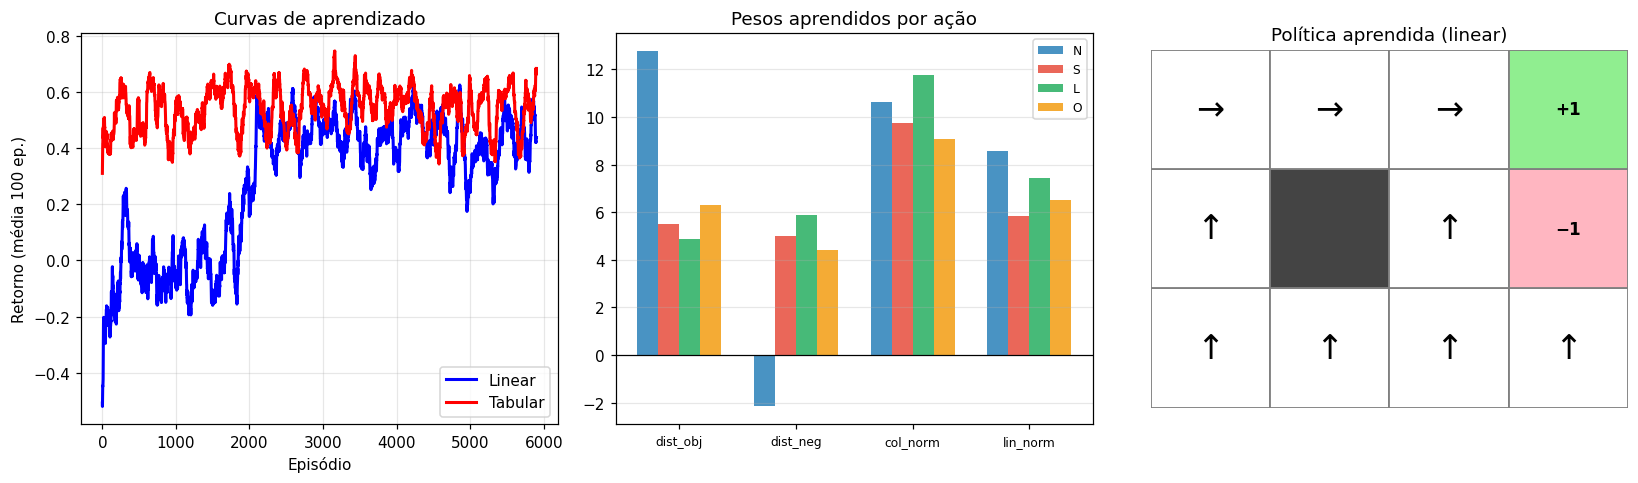

In [30]:
"""
12_qlearning_linear.py — Seção 7: Q-learning com aproximação linear
Q(s,a) = w · f(s,a)  com features de estado-ação em blocos.
Treina no Mundo Grade, exibe os pesos aprendidos e a política.
Compara diretamente com a versão tabular.
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Mundo Grade 4×3 ──────────────────────────────────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})
NAO_T    = [s for s in ESTADOS if s not in ((4, 3), (4, 2))]
T_POS, T_NEG = (4, 3), (4, 2)
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}
PERP     = {'N': ('O', 'L'), 'S': ('L', 'O'), 'L': ('N', 'S'), 'O': ('S', 'N')}
D_MAX    = 6.0

def mover(s, a):
    c, r = s; dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s

def amostrar(s, a):
    ae, ad = PERP[a]
    return random.choices([mover(s,a), mover(s,ae), mover(s,ad)],
                          weights=[0.8, 0.1, 0.1])[0]

def recomp(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

# ── Features de estado (4 features, normalizadas) ─────────────
NOMES_F = ['dist_obj', 'dist_neg', 'col_norm', 'lin_norm']
N_F = 4

def feat_estado(s):
    return np.array([
        (abs(s[0]-T_POS[0]) + abs(s[1]-T_POS[1])) / D_MAX,   # dist. ao +1
        (abs(s[0]-T_NEG[0]) + abs(s[1]-T_NEG[1])) / D_MAX,   # dist. ao -1
        (s[0] - 1) / 3.0,                                       # coluna normalizada
        (s[1] - 1) / 2.0,                                       # linha normalizada
    ])

def phi(s, a):
    """Vetor de estado-ação: N_F × |ACOES| — só o bloco da ação a é não-zero."""
    idx = ACOES.index(a)
    v   = np.zeros(N_F * len(ACOES))
    v[idx * N_F : (idx + 1) * N_F] = feat_estado(s)
    return v

def Q_aprox(s, a, w):
    return float(w @ phi(s, a))

# ── Q-learning com aproximação linear ────────────────────────
def treinar_linear(n_ep=6000, alpha=0.02, gamma=0.9, eps=0.25, seed=42):
    random.seed(seed)
    w = np.zeros(N_F * len(ACOES))
    retornos = []
    for _ in range(n_ep):
        s = random.choice(NAO_T)
        G = 0.0
        for _ in range(120):
            if s in (T_POS, T_NEG): break
            a  = (random.choice(ACOES) if random.random() < eps
                  else max(ACOES, key=lambda x: Q_aprox(s, x, w)))
            s2 = amostrar(s, a)
            r  = recomp(s2)
            G += r
            max_q2 = max(Q_aprox(s2, x, w) for x in ACOES)
            delta  = r + gamma * max_q2 - Q_aprox(s, a, w)
            w     += alpha * delta * phi(s, a)       # ← regra central
            s = s2
        retornos.append(G)
    return w, retornos

# ── Q-learning tabular (referência) ──────────────────────────
def treinar_tabular(n_ep=6000, alpha=0.3, gamma=0.9, eps=0.2, seed=42):
    random.seed(seed)
    Q = defaultdict(float)
    retornos = []
    for _ in range(n_ep):
        s = random.choice(NAO_T)
        G = 0.0
        for _ in range(120):
            if s in (T_POS, T_NEG): break
            a  = (random.choice(ACOES) if random.random() < eps
                  else max(ACOES, key=lambda x: Q[(s, x)]))
            s2 = amostrar(s, a)
            r  = recomp(s2)
            G += r
            Q[(s, a)] += alpha * (r + gamma * max(Q[(s2, x)] for x in ACOES) - Q[(s, a)])
            s = s2
        retornos.append(G)
    return Q, retornos

w_final, ret_lin = treinar_linear()
Q_tab,   ret_tab = treinar_tabular()

politica_lin = {s: max(ACOES, key=lambda a: Q_aprox(s, a, w_final)) for s in NAO_T}
politica_tab = {s: max(ACOES, key=lambda a: Q_tab[(s, a)])           for s in NAO_T}
SETA = {'N': '↑', 'S': '↓', 'L': '→', 'O': '←'}

# ── Impressão ─────────────────────────────────────────────────
print("=" * 60)
print("  Q-learning com Aproximação Linear — Mundo Grade")
print("=" * 60)
print("\n  Pesos aprendidos  w  (por bloco de ação):")
print(f"  {'Ação':>4}   " + "  ".join(f"{n:>10}" for n in NOMES_F))
print("  " + "─" * 52)
for i, a in enumerate(ACOES):
    bloco = w_final[i * N_F:(i + 1) * N_F]
    print(f"  {a:>4}   " + "  ".join(f"{v:>+10.4f}" for v in bloco))

print("\n  Comparação de políticas (Tab = tabular, Lin = linear):")
for row in range(3, 0, -1):
    lin = "  lin%d  " % row
    for col in range(1, 5):
        s = (col, row)
        if   s == (2, 2): lin += "  ██  "
        elif s == T_POS:  lin += " [+1] "
        elif s == T_NEG:  lin += " [-1] "
        else:             lin += f" {SETA[politica_lin[s]]}/{SETA[politica_tab[s]]} "
    print(lin)
print("  (Lin/Tab — divergências indicam onde a aproximação linear difere)")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Curvas de aprendizado
ax = axes[0]
ww = 100
for ret, cor, lbl in [(ret_lin,'b','Linear'), (ret_tab,'r','Tabular')]:
    ma = np.convolve(ret, np.ones(ww)/ww, mode='valid')
    ax.plot(ma, '-', color=cor, lw=2, label=lbl)
ax.set_xlabel('Episódio'); ax.set_ylabel(f'Retorno (média {ww} ep.)')
ax.set_title('Curvas de aprendizado'); ax.legend(); ax.grid(True, alpha=0.3)

# Pesos finais por bloco
ax2 = axes[1]
x = np.arange(N_F)
w_bp = 0.18
CORES = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12']
for i, (a, c) in enumerate(zip(ACOES, CORES)):
    ax2.bar(x + i * w_bp, w_final[i*N_F:(i+1)*N_F],
            w_bp, label=a, color=c, alpha=0.85)
ax2.set_xticks(x + 1.5*w_bp); ax2.set_xticklabels(NOMES_F, fontsize=8)
ax2.axhline(0, color='k', lw=0.8)
ax2.set_title('Pesos aprendidos por ação'); ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# Grade: política linear
ax3 = axes[2]
ax3.set_xlim(0.5, 4.5); ax3.set_ylim(0.5, 3.5)
ax3.set_aspect('equal'); ax3.axis('off')
ax3.set_title('Política aprendida (linear)')
for col in range(1, 5):
    for row in range(1, 4):
        s = (col, row)
        fc = ('#444' if s==(2,2) else '#90EE90' if s==T_POS
              else '#FFB6C1' if s==T_NEG else 'white')
        ax3.add_patch(plt.Rectangle((col-.5,row-.5),1,1,ec='gray',fc=fc,lw=1.2))
        if   s == T_POS: ax3.text(col,row,'+1',ha='center',va='center',
                                  fontsize=11,fontweight='bold')
        elif s == T_NEG: ax3.text(col,row,'−1',ha='center',va='center',
                                  fontsize=11,fontweight='bold')
        elif s != (2,2): ax3.text(col,row,SETA[politica_lin[s]],
                                  ha='center',va='center',fontsize=22)

plt.tight_layout()
plt.savefig('./12_qlearning_linear.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 7c — Generalização Boa vs Ruim
**Conceito:** dois estados com features semelhantes mas consequências opostas.  
Demonstra a necessidade de features que capturem risco local.


  Generalização Boa vs Ruim — Aproximação Linear

  ── Par 1: generalização útil ────────────────────────────
  f((1, 1))  = [0.8333 0.6667]  →  Leste leva a (2, 1) (seguro)
  f((2, 1))  = [0.6667 0.5   ]  →  Leste leva a (3, 1) (seguro)
  ‖Δf‖ = 0.2357  — semelhantes E com consequências parecidas ✓

  ── Par 2: generalização indevida ────────────────────────
  f((3, 3))  = [0.1667 0.3333]  →  Leste leva a (4, 3) = (4, 3)  🎯
  f((3, 2))  = [0.3333 0.1667]  →  Leste leva a (4, 2) = (4, 2)  ☠
  ‖Δf‖ = 0.2357  — semelhantes MAS consequências opostas ✗

  ── Q linear (2 features) para a ação Leste ─────────────
  Q((3, 3), Leste) = -0.1500  (correto: deveria ser alto)
  Q((3, 2), Leste) = -0.4500  (errado: deveria ser baixo)
  Diferença: 0.3000  — modelo quase não os distingue!

  ── Com feature de adjacência ao terminal negativo ────────
  f_ext((3, 3)) = [0.1667 0.3333 0.    ]  (não adjacente ao −1)
  f_ext((3, 2)) = [0.3333 0.1667 1.    ]  (adjacente ao −1 ← flag ativo!)
  ‖Δf_ext‖ = 1.

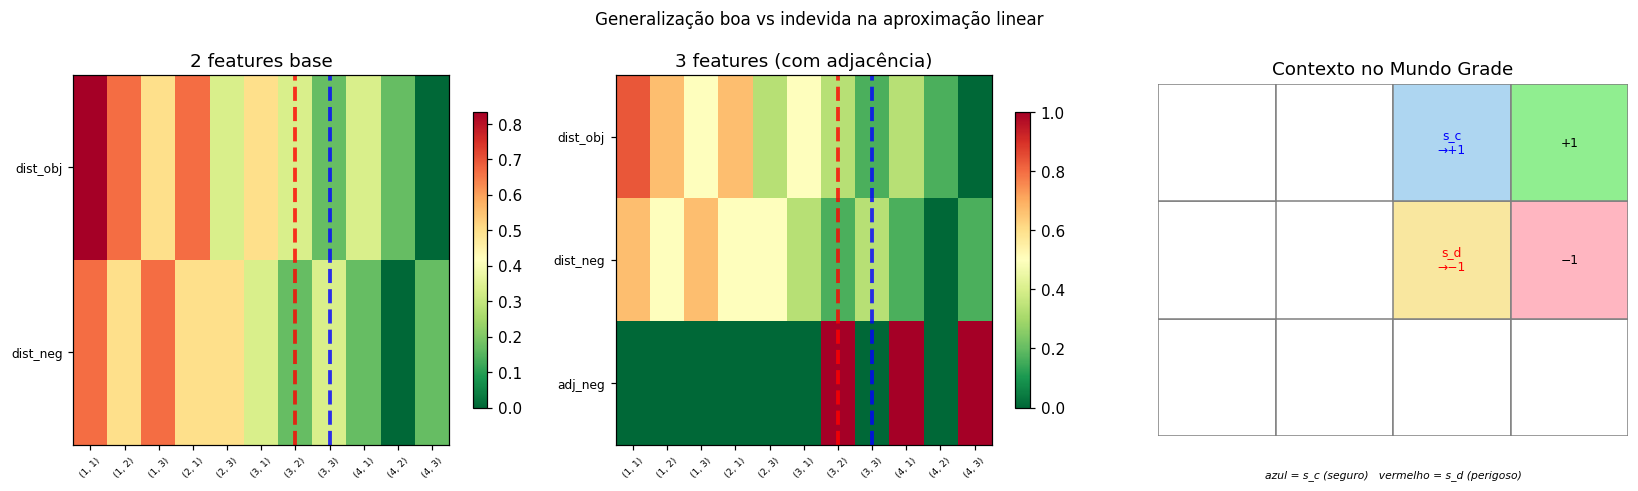

In [31]:
"""
13_generalizacao_boa_ruim.py — Seção 7: Generalização indevida
Demonstra que dois estados com features semelhantes mas contextos
diferentes recebem valores Q parecidos quando usamos aproximação linear.
Mostra como uma feature adicional corrige o problema.
"""
import numpy as np
import matplotlib.pyplot as plt

T_POS = (4, 3)
T_NEG = (4, 2)
D_MAX = 6.0

# ── Features base (apenas 2: distâncias ao +1 e ao -1) ────────
def feat_base(s):
    d_pos = (abs(s[0]-T_POS[0]) + abs(s[1]-T_POS[1])) / D_MAX
    d_neg = (abs(s[0]-T_NEG[0]) + abs(s[1]-T_NEG[1])) / D_MAX
    return np.array([d_pos, d_neg])

def feat_com_adjacencia(s):
    """Feature adicional: está adjacente ao terminal negativo?"""
    adjacente = 1.0 if (abs(s[0]-T_NEG[0]) + abs(s[1]-T_NEG[1])) == 1 else 0.0
    return np.append(feat_base(s), adjacente)

ACOES = ['N', 'S', 'L', 'O']

# ── Par 1: generalização boa ─────────────────────────────────
s_a = (1, 1)   # canto inferior esquerdo
s_b = (2, 1)   # um passo à direita

# ── Par 2: generalização indevida ────────────────────────────
s_c = (3, 3)   # próximo do +1, ação Leste → T_POS  (ótima)
s_d = (3, 2)   # mesma coluna,  ação Leste → T_NEG  (péssima)

print("=" * 65)
print("  Generalização Boa vs Ruim — Aproximação Linear")
print("=" * 65)

print("\n  ── Par 1: generalização útil ────────────────────────────")
fa, fb = feat_base(s_a), feat_base(s_b)
print(f"  f({s_a})  = {np.round(fa, 4)}  →  Leste leva a {(s_a[0]+1, s_a[1])} (seguro)")
print(f"  f({s_b})  = {np.round(fb, 4)}  →  Leste leva a {(s_b[0]+1, s_b[1])} (seguro)")
print(f"  ‖Δf‖ = {np.linalg.norm(fa-fb):.4f}  — semelhantes E com consequências parecidas ✓")

print("\n  ── Par 2: generalização indevida ────────────────────────")
fc, fd = feat_base(s_c), feat_base(s_d)
print(f"  f({s_c})  = {np.round(fc, 4)}  →  Leste leva a {(s_c[0]+1, s_c[1])} = {T_POS}  🎯")
print(f"  f({s_d})  = {np.round(fd, 4)}  →  Leste leva a {(s_d[0]+1, s_d[1])} = {T_NEG}  ☠")
print(f"  ‖Δf‖ = {np.linalg.norm(fc-fd):.4f}  — semelhantes MAS consequências opostas ✗")

# ── Simulação com pesos simplificados ────────────────────────
print("\n  ── Q linear (2 features) para a ação Leste ─────────────")
# Pesos hipotéticos: o modelo aprendeu a valorizar "perto do objetivo"
N_F, N_A = 2, len(ACOES)
w = np.zeros(N_F * N_A)
idx_L = ACOES.index('L')
w[idx_L*N_F : (idx_L+1)*N_F] = np.array([-1.5, 0.3])  # penaliza dist_pos, ignora dist_neg

def phi(s, a, n_f=2):
    idx = ACOES.index(a)
    v   = np.zeros(n_f * N_A)
    v[idx*n_f : (idx+1)*n_f] = feat_base(s)
    return v

Q_sc = float(w @ phi(s_c, 'L'))
Q_sd = float(w @ phi(s_d, 'L'))
print(f"  Q({s_c}, Leste) = {Q_sc:+.4f}  (correto: deveria ser alto)")
print(f"  Q({s_d}, Leste) = {Q_sd:+.4f}  (errado: deveria ser baixo)")
print(f"  Diferença: {abs(Q_sc-Q_sd):.4f}  — modelo quase não os distingue!")

# ── Feature adicional que corrige o problema ──────────────────
print("\n  ── Com feature de adjacência ao terminal negativo ────────")
fc_ext = feat_com_adjacencia(s_c)
fd_ext = feat_com_adjacencia(s_d)
print(f"  f_ext({s_c}) = {np.round(fc_ext, 4)}  (não adjacente ao −1)")
print(f"  f_ext({s_d}) = {np.round(fd_ext, 4)}  (adjacente ao −1 ← flag ativo!)")
print(f"  ‖Δf_ext‖ = {np.linalg.norm(fc_ext-fd_ext):.4f}  — agora são distinguíveis ✓")
print("\n  Com um peso negativo forte em 'adjacente_neg', o modelo aprenderia")
print("  a penalizar (s_d, Leste), sem afetar (s_c, Leste).")

# ── Gráfico ───────────────────────────────────────────────────
ESTADOS_V = [(c,r) for c in range(1,5) for r in range(1,4) if (c,r) != (2,2)]
mat2 = np.array([feat_base(s) for s in ESTADOS_V])
mat3 = np.array([feat_com_adjacencia(s) for s in ESTADOS_V])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax_idx, (mat, nomes_col, titulo) in enumerate([
        (mat2, ['dist_obj','dist_neg'],         '2 features base'),
        (mat3, ['dist_obj','dist_neg','adj_neg'],'3 features (com adjacência)')]):
    ax = axes[ax_idx]
    im = ax.imshow(mat.T, aspect='auto', cmap='RdYlGn_r')
    ax.set_yticks(range(len(nomes_col))); ax.set_yticklabels(nomes_col, fontsize=8)
    ax.set_xticks(range(len(ESTADOS_V)))
    ax.set_xticklabels([str(s) for s in ESTADOS_V], rotation=45, fontsize=6)
    ax.set_title(titulo)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for s, cor in [(s_c, 'blue'), (s_d, 'red')]:
        idx = ESTADOS_V.index(s)
        ax.axvline(idx, color=cor, lw=2.5, ls='--', alpha=0.8)

# Grade contextual
ax3 = axes[2]
ax3.set_xlim(0.5, 4.5); ax3.set_ylim(0.5, 3.5)
ax3.set_aspect('equal'); ax3.axis('off')
ax3.set_title('Contexto no Mundo Grade')
for col in range(1, 5):
    for row in range(1, 4):
        s = (col, row)
        if s == (2,2): continue
        fc = ('#90EE90' if s == T_POS else '#FFB6C1' if s == T_NEG else
              '#aed6f1' if s == s_c   else '#f9e79f' if s == s_d else 'white')
        ax3.add_patch(plt.Rectangle((col-.5,row-.5),1,1, ec='gray', fc=fc, lw=1))
        label = ('+1' if s==T_POS else '−1' if s==T_NEG else
                 f's_c\n→+1' if s==s_c else f's_d\n→−1' if s==s_d else '')
        color = ('black' if s in (T_POS,T_NEG) else 'blue' if s==s_c else
                 'red'   if s==s_d else 'black')
        if label:
            ax3.text(col, row, label, ha='center', va='center', fontsize=8, color=color)

ax3.text(2.5, 0.15, 'azul = s_c (seguro)   vermelho = s_d (perigoso)',
         ha='center', fontsize=7, style='italic')

plt.suptitle('Generalização boa vs indevida na aproximação linear', fontsize=11)
plt.tight_layout()
plt.savefig('./13_generalizacao_boa_ruim.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Seção 8 — Reward Shaping baseado em Potencial
**Conceito:** F(s,s') = γ·Φ(s') − Φ(s), shaping bom vs ruim,  
efeito na velocidade de convergência.


  Reward Shaping baseado em potencial — Mundo Grade

  ─── Exemplo numérico ────────────────────────────────────
  Estado atual s = (1, 1)  →  próximo estado s' = (1, 2)

  Φ_bom((1, 1))  = 0.1667
  Φ_bom((1, 2)) = 0.3333
  F_bom = γ·Φ((1, 2)) − Φ((1, 1)) = 0.9×0.3333 − 0.1667 = +0.1333
  → Transição recebe bônus positivo: agente se aproximou do objetivo.

  Φ_ruim((1, 1))  = 0.3333
  Φ_ruim((1, 2)) = 0.5000
  F_ruim = γ·Φ((1, 2)) − Φ((1, 1)) = 0.9×0.5000 − 0.3333 = +0.1167
  → Shaping ruim: penaliza por se afastar do perigo (enganoso!).

  ─── Retorno médio (últimos 100 episódios) ───────────────
  Sem shaping:   0.4336
  Shaping bom:   0.4452
  Shaping ruim:  0.4616


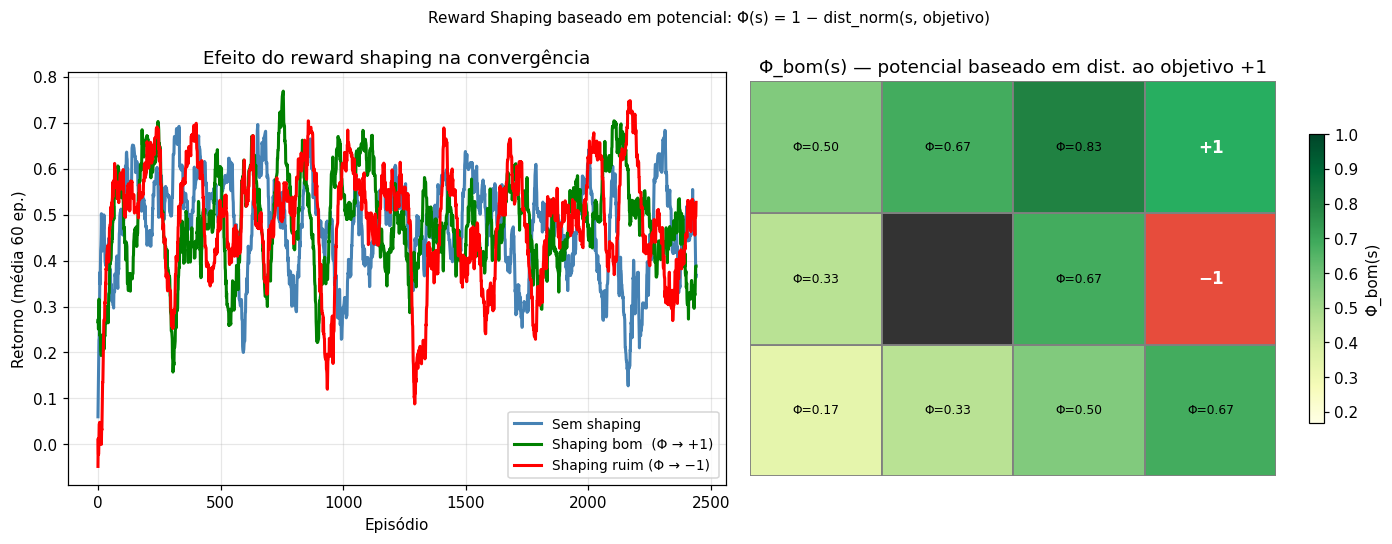

In [32]:
"""
14_reward_shaping.py — Seção 8: Reward Shaping
Compara Q-learning no Mundo Grade em três cenários:
  1. Sem shaping
  2. Shaping bom:  Φ(s) ∝ proximidade ao terminal +1
  3. Shaping ruim: Φ(s) ∝ proximidade ao terminal −1  (enganoso)
Mostra o efeito na velocidade de convergência e inclui exemplo numérico.
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Mundo Grade 4×3 ──────────────────────────────────────────
ESTADOS  = sorted({(c, r) for c in range(1, 5)
                   for r in range(1, 4)} - {(2, 2)})
NAO_T    = [s for s in ESTADOS if s not in ((4, 3), (4, 2))]
T_POS, T_NEG = (4, 3), (4, 2)
ACOES    = ['N', 'S', 'L', 'O']
DELTA    = {'N': (0, 1), 'S': (0, -1), 'L': (1, 0), 'O': (-1, 0)}
PERP     = {'N': ('O', 'L'), 'S': ('L', 'O'), 'L': ('N', 'S'), 'O': ('S', 'N')}
D_MAX    = 6.0

def mover(s, a):
    c, r = s; dc, dr = DELTA[a]
    s2 = (c + dc, r + dr)
    return s2 if s2 in ESTADOS else s

def amostrar(s, a):
    ae, ad = PERP[a]
    return random.choices([mover(s,a), mover(s,ae), mover(s,ad)],
                          weights=[0.8, 0.1, 0.1])[0]

def recomp(s):
    return {T_POS: +1.0, T_NEG: -1.0}.get(s, -0.04)

# ── Funções potencial ─────────────────────────────────────────
def phi_bom(s):
    """Φ(s) = 1 − dist(s, terminal+) / D_MAX  [↑ perto do objetivo]"""
    d = abs(s[0]-T_POS[0]) + abs(s[1]-T_POS[1])
    return 1.0 - d / D_MAX

def phi_ruim(s):
    """Φ(s) = 1 − dist(s, terminal−) / D_MAX  [↑ perto do perigo — enganoso!]"""
    d = abs(s[0]-T_NEG[0]) + abs(s[1]-T_NEG[1])
    return 1.0 - d / D_MAX

def shaping(s, s2, gamma, phi_fn):
    """F(s,s') = γ·Φ(s') − Φ(s)"""
    return gamma * phi_fn(s2) - phi_fn(s)

# ── Exemplo numérico (reproduz o texto) ──────────────────────
GAMMA = 0.9
s_ex, s2_bom, s2_ruim = (1, 1), (1, 2), (2, 1)

print("=" * 60)
print("  Reward Shaping baseado em potencial — Mundo Grade")
print("=" * 60)
print()
print("  ─── Exemplo numérico ────────────────────────────────────")
print(f"  Estado atual s = {s_ex}  →  próximo estado s' = {s2_bom}")
print(f"\n  Φ_bom({s_ex})  = {phi_bom(s_ex):.4f}")
print(f"  Φ_bom({s2_bom}) = {phi_bom(s2_bom):.4f}")
F_bom = shaping(s_ex, s2_bom, GAMMA, phi_bom)
print(f"  F_bom = γ·Φ({s2_bom}) − Φ({s_ex})"
      f" = {GAMMA}×{phi_bom(s2_bom):.4f} − {phi_bom(s_ex):.4f} = {F_bom:+.4f}")
print(f"  → Transição recebe bônus positivo: agente se aproximou do objetivo.\n")

print(f"  Φ_ruim({s_ex})  = {phi_ruim(s_ex):.4f}")
print(f"  Φ_ruim({s2_bom}) = {phi_ruim(s2_bom):.4f}")
F_ruim = shaping(s_ex, s2_bom, GAMMA, phi_ruim)
print(f"  F_ruim = γ·Φ({s2_bom}) − Φ({s_ex})"
      f" = {GAMMA}×{phi_ruim(s2_bom):.4f} − {phi_ruim(s_ex):.4f} = {F_ruim:+.4f}")
print(f"  → Shaping ruim: penaliza por se afastar do perigo (enganoso!).\n")

# ── Treinamento comparativo ────────────────────────────────────
def treinar(n_ep=2500, alpha=0.3, gamma=0.9, eps=0.3,
            phi_fn=None, seed=0):
    random.seed(seed)
    Q = defaultdict(float)
    retornos = []
    for _ in range(n_ep):
        s = random.choice(NAO_T)
        G = 0.0
        for _ in range(120):
            if s in (T_POS, T_NEG): break
            a  = (random.choice(ACOES) if random.random() < eps
                  else max(ACOES, key=lambda x: Q[(s, x)]))
            s2 = amostrar(s, a)
            r  = recomp(s2)
            F  = shaping(s, s2, gamma, phi_fn) if phi_fn else 0.0
            G += r
            max_q2 = max(Q[(s2, x)] for x in ACOES)
            Q[(s, a)] += alpha * (r + F + gamma * max_q2 - Q[(s, a)])
            s = s2
        retornos.append(G)
    return Q, retornos

Q_sem,  ret_sem  = treinar(phi_fn=None,     seed=1)
Q_bom,  ret_bom  = treinar(phi_fn=phi_bom,  seed=1)
Q_ruim, ret_ruim = treinar(phi_fn=phi_ruim, seed=1)

w = 100
print("  ─── Retorno médio (últimos 100 episódios) ───────────────")
print(f"  Sem shaping:   {np.mean(ret_sem[-w:]):.4f}")
print(f"  Shaping bom:   {np.mean(ret_bom[-w:]):.4f}")
print(f"  Shaping ruim:  {np.mean(ret_ruim[-w:]):.4f}")

# ── Gráfico ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ww = 60
ax = axes[0]
for ret, cor, lbl in [(ret_sem, 'steelblue', 'Sem shaping'),
                      (ret_bom, 'green',      'Shaping bom  (Φ → +1)'),
                      (ret_ruim,'red',         'Shaping ruim (Φ → −1)')]:
    ma = np.convolve(ret, np.ones(ww)/ww, mode='valid')
    ax.plot(ma, '-', color=cor, lw=2, label=lbl)
ax.set_xlabel('Episódio'); ax.set_ylabel(f'Retorno (média {ww} ep.)')
ax.set_title('Efeito do reward shaping na convergência')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Mapa de Φ_bom sobre a grade
ax2 = axes[1]
ax2.set_xlim(0.5, 4.5); ax2.set_ylim(0.5, 3.5)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Φ_bom(s) — potencial baseado em dist. ao objetivo +1')

phi_vals = {s: phi_bom(s) for s in ESTADOS}
vmin, vmax = min(phi_vals.values()), max(phi_vals.values())
cmap = plt.cm.YlGn

for col in range(1, 5):
    for row in range(1, 4):
        s = (col, row)
        if s == (2, 2):
            fc = '#333'
        elif s == T_POS:
            fc = '#27ae60'
        elif s == T_NEG:
            fc = '#e74c3c'
        else:
            t = (phi_vals[s] - vmin) / (vmax - vmin + 1e-9)
            fc = cmap(0.2 + 0.7 * t)
        ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, ec='gray', fc=fc, lw=1.2))
        if s == T_POS:
            ax2.text(col, row, '+1', ha='center', va='center',
                     fontsize=11, fontweight='bold', color='white')
        elif s == T_NEG:
            ax2.text(col, row, '−1', ha='center', va='center',
                     fontsize=11, fontweight='bold', color='white')
        elif s != (2, 2):
            ax2.text(col, row, f'Φ={phi_vals[s]:.2f}',
                     ha='center', va='center', fontsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax2, shrink=0.7, label='Φ_bom(s)')

plt.suptitle('Reward Shaping baseado em potencial: Φ(s) = 1 − dist_norm(s, objetivo)',
             fontsize=10)
plt.tight_layout()
plt.savefig('./14_reward_shaping.png',
            dpi=130, bbox_inches='tight')
plt.show()


---
## Resumo dos Algoritmos

| Algoritmo | Tipo | Alvo de atualização | Generalização |
|-----------|------|----------------------|---------------|
| Q-learning tabular | off-policy | r + γ max Q(s',a') | Nenhuma |
| SARSA tabular | on-policy | r + γ Q(s',a') | Nenhuma |
| Q-learning linear | off-policy | r + γ max Q(s',a') | Via features |

> **Mensagem central:** o Q-learning tabular aprende valores exatos mas não escala.
> A aproximação linear escala e generaliza, mas exige boas features.
> A escolha da representação é tão importante quanto o algoritmo de aprendizado.
